# 12. Representacion de criticidad via gates de arista por muestra (M-GCECDL)

Pivote auto-supervisado: `MGCECDLRegressor` se usa exclusivamente como
autoencoder -- `x -> encode -> z -> gates -> propagate -> encode -> decode ->
x_hat` -- entrenado UNICAMENTE contra su propia reconstruccion de `x`, el
kernel del grafo experto fijo, y un prior de desviacion de gate. Ningun
objetivo supervisado entra jamas a la perdida.

Los clusters son regimenes de grafo por vano sobre el vector de gates de
dimension `E`; se validan contra una cantidad que el modelo NUNCA vio durante
el entrenamiento -- el `UITI_VANO` futuro acumulado por vano, en una
particion cronologicamente FUTURA.

Generado por `scripts/generate_notebook_12.py` (COMMITTED, reproducible --
a diferencia del generador de la libreta 11, que vivia fuera de este
repositorio). Ver `sdd/notebook-12-criticality-representation/{spec,design}`
para el contrato completo.


## Diagrama del flujo de datos

```mermaid
flowchart TD
    A["procesar_dataset_completo (seleccion nb12-local)"] --> B["reinyectar_target_como_feature (UITI_VANO)"]
    B --> C["construir_edge_index (adyacencia experta fija)"]
    C --> D["split_cronologico_p70 (pasado / futuro)"]
    D --> E["entrenar_gated_autoencoder (SOLO pasado)"]
    E --> F["agrupar_gates_por_vano"]
    F --> G["KMeans (K derivado de los datos)"]
    G --> H["asociacion_criticidad vs UITI_VANO futuro acumulado"]
```


In [1]:
# Celda de parametros (papermill). Sobrescribir con `-p mode full` para la corrida real.
# El default es "smoke" a proposito -- ver la libreta 11 para el mismo patron.
mode = "smoke"


In [2]:
# Parameters
mode = "full"


## Bootstrap: raiz del repo, `sys.path` y guarda de precondiciones

Sigue el mismo patron obligatorio que la libreta 11: falla rapido y con un
mensaje accionable si los modulos de la representacion gated no son
importables.


In [3]:
import sys
from pathlib import Path


# Sube desde el cwd hasta el checkout, para correr desde cualquier directorio.
def resolve_project_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "src" / "chec_impacto").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError(
        "No se encontro la raiz del proyecto (se busco un directorio con src/chec_impacto/ "
        "y data/ subiendo desde el cwd). Ejecuta este cuaderno desde el checkout."
    )


PROJECT_ROOT = resolve_project_root()
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "reports" / "interpretability" / "figures"
MODELS_DIR = DATA_DIR / "models"

for path_to_add in (PROJECT_ROOT, SRC_DIR):
    if str(path_to_add) not in sys.path:
        sys.path.insert(0, str(path_to_add))
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:    ", DATA_DIR)
print("FIGURES_DIR: ", FIGURES_DIR)
print("MODELS_DIR:  ", MODELS_DIR)

# --- Guarda de precondiciones: sonda de import, nunca una implementacion sustituta ---
try:
    from chec_impacto.models import (
        GatedSelfSupervisedLoss,
        GraphGatedMGCECDLRegressor,
        cargar_modelo_gated,
        construir_edge_index,
        entrenar_gated_autoencoder,
        guardar_modelo_gated,
        reinyectar_target_como_feature,
    )
    from chec_impacto.interpretability import (
        afinidad_entre_grafos,
        agrupar_gates_por_vano,
        anidamiento_entre_particiones,
        asignar_nombres_de_riesgo,
        asociacion_criticidad,
        assert_fecha_excluded_from_features,
        control_permutacion_grados,
        diagnostico_persistencia,
        ejecutar_control_permutacion_grados,
        estabilidad_por_submuestreo,
        estadistico_colapso,
        grafo_reconstruido_por_grupo,
        guardia_proxy_univariante,
        linea_base_sin_grafo,
        perfil_por_cluster,
        separabilidad_fuera_de_pliegue,
        seleccionar_k_datos,
        split_cronologico_p70,
        tabla_desviacion_aristas,
        tabla_grado_features,
        uiti_futuro_por_vano,
        verificar_orden_de_riesgo,
    )
    from chec_impacto.models import (
        LAMBDA_DEV_CHOICES,
        LAMBDA_MI_CHOICES,
        construir_objetivo_gated,
        mean_pairwise_ari,
        resumen_barrido_lambda_dev,
        resumen_barrido_lambda_mi,
    )
except ImportError as exc:
    raise SystemExit(
        "Los modulos de la representacion gated (models/mgcecdl_graph.py, "
        "interpretability/mgcecdl_graph.py, models/mgcecdl_graph_search.py) no son "
        f"importables desde {SRC_DIR}. Verifica que corres desde el checkout y que el "
        "entorno tiene torch/optuna/umap instalados (pip install -r requirements.txt)."
    ) from exc

from scripts.build_nb12_variable_selection import build_nb12_variable_selection

print("Guarda OK: modulos de la representacion gated (PR1 + PR2) importables.")


PROJECT_ROOT: /Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter
DATA_DIR:     /Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/data
FIGURES_DIR:  /Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/reports/interpretability/figures
MODELS_DIR:   /Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/data/models


Guarda OK: modulos de la representacion gated (PR1 + PR2) importables.


In [4]:
import time

import numpy as np
import pandas as pd
import torch
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from chec_impacto.data import construir_matriz_adyacencia_mgcecdl, procesar_dataset_completo
from chec_impacto.models import MGCECDLRegressor
from chec_impacto.training import (
    calcular_estadisticas_reconstruccion_mgcecdl,
    construir_modalidades_mgcecdl,
    resolve_training_device,
    run_optuna_study,
)

RANDOM_STATE = 42
DEVICE = resolve_training_device("auto")
print("Dispositivo de entrenamiento resuelto:", DEVICE)
if DEVICE.type == "cpu":
    print("AVISO: se entrenara en CPU. Con mode='full' esto puede tardar horas.")


Dispositivo de entrenamiento resuelto: mps


## Configuracion del presupuesto (`smoke` vs `full`) y quiebre de semillas

Sigue el diseno D3: las semillas de BUSQUEDA (`SEEDS_SEARCH`) estan
CUARENTENADAS de las semillas de la compuerta de aceptacion (`SEEDS_GATE`) --
optimizar y evaluar con el mismo conjunto de semillas destruiria el valor
evidencial de la compuerta. `K_SEARCH` es una constante de tiempo de
busqueda unicamente; el K reportado se deriva de los datos mas adelante.


In [5]:
if mode not in ("smoke", "full"):
    raise ValueError(f"mode desconocido: {mode!r} -- se esperaba 'smoke' o 'full'.")

# Semillas de busqueda: nunca se re-usan para evaluar la compuerta de aceptacion.
SEEDS_SEARCH = (0, 1, 2)
# K_SEARCH es una constante de tiempo de BUSQUEDA unicamente -- el objetivo de Optuna
# nunca devuelve un "K": el K reportado se deriva de los datos mas abajo
# (seleccionar_k_datos), nunca sustituido silenciosamente por este valor.
K_SEARCH = 4

if mode == "smoke":
    # Prueba de cableado: submuestra pequena y presupuesto minimo.
    SEEDS_GATE = (10, 11)
    SMOKE_EVENT_SUBSAMPLE = 2000
    TAU_REFERENCE_EPOCHS = 2
    SEARCH_EPOCHS = 2
    OPTUNA_N_TRIALS = 2
    LAMBDA_SWEEP_EPOCHS = 2
    GATE_EPOCHS = 2
    ABLATION_EPOCHS = 2
    COST_CEILING_SECONDS = 900.0
else:
    # Semillas de la compuerta de aceptacion: 5, disjuntas de SEEDS_SEARCH (diseno D3).
    SEEDS_GATE = (10, 11, 12, 13, 14)
    SMOKE_EVENT_SUBSAMPLE = None
    TAU_REFERENCE_EPOCHS = 20
    SEARCH_EPOCHS = 20
    OPTUNA_N_TRIALS = 10
    LAMBDA_SWEEP_EPOCHS = 20
    GATE_EPOCHS = 30
    ABLATION_EPOCHS = 20
    # Techo declarado por el usuario para la fase costosa (busqueda Optuna): si la
    # proyeccion de la celda de pronostico de costo lo supera, NO se lanza la busqueda
    # completa y se usan hiperparametros de respaldo en su lugar.
    COST_CEILING_SECONDS = 4.0 * 3600.0

ARI_STABILITY_THRESHOLD = 0.3

# Niveles de riesgo que se ENTREGAN (pedido operativo). K_ENTREGA se deriva de
# esta lista, nunca de un literal suelto, y el orden define el significado
# ordinal que la seccion 23 asigna por UITI_VANO acumulado medio ascendente.
NOMBRES_RIESGO = ("Bajo", "Medio", "Medio-Alto", "Alto")
# Clave de ordenamiento de los niveles. MEDIANA, no media: UITI_VANO acumulado es de
# cola muy pesada (la media de un grupo corre varias veces su propia mediana), asi que
# ordenar por media ordena por quien sufrio el peor evento y no por quien es
# persistentemente critico. La corrida completa anterior lo mostro: por media, los tres
# niveles inferiores quedaron dentro del 6.5% y la mediana los ordenaba al reves.
ESTADISTICO_DE_RIESGO = "mediana"

print(f"mode={mode!r} | SEEDS_SEARCH={SEEDS_SEARCH} | SEEDS_GATE={SEEDS_GATE} | K_SEARCH={K_SEARCH}")
print(f"COST_CEILING_SECONDS={COST_CEILING_SECONDS}")
print(f"NOMBRES_RIESGO={NOMBRES_RIESGO} -> K_ENTREGA={len(NOMBRES_RIESGO)}")
print(f"ESTADISTICO_DE_RIESGO={ESTADISTICO_DE_RIESGO!r}")


mode='full' | SEEDS_SEARCH=(0, 1, 2) | SEEDS_GATE=(10, 11, 12, 13, 14) | K_SEARCH=4
COST_CEILING_SECONDS=14400.0
NOMBRES_RIESGO=('Bajo', 'Medio', 'Medio-Alto', 'Alto') -> K_ENTREGA=4
ESTADISTICO_DE_RIESGO='mediana'


## 1. Carga de datos: seleccion nb12-local + reinyeccion de `UITI_VANO`

La seleccion nb12-local recupera `DURACION, TOT_USUS, UITI, COD_CAUSA` sobre
la seleccion compartida (`data/Variables_seleccion.xlsx`, jamas modificada
-- ver `scripts/build_nb12_variable_selection.py`). `UITI_VANO` se reinyecta
como feature endogena porque `preprocessing.py` la excluye de `features`
deliberadamente (ver D5 del diseno).


In [6]:
VENTANA_CLIMATICA_HORAS = 12
FILTRO_UITI_MAX = None

DATASET_PATH = DATA_DIR / "Indicadores_vano_v3.csv"
derived_selection_path = build_nb12_variable_selection()
print("Seleccion derivada nb12-local:", derived_selection_path)

datos_procesados = procesar_dataset_completo(
    path_clima=DATASET_PATH,
    path_variables_seleccion=derived_selection_path,
    use_sampling=False,
    min_samples_per_codigo=5,
    target="UITI_VANO",
    filtro_uiti_max=FILTRO_UITI_MAX,
    ventana_climatica_horas=VENTANA_CLIMATICA_HORAS,
)

assert "UITI_VANO" not in datos_procesados["features"], (
    "UITI_VANO no debe estar en features antes de la reinyeccion explicita "
    "(preprocessing.py excluye el target de X por diseno)."
)

X_without_target = datos_procesados["X"]
features_without_target = list(datos_procesados["features"])

X_with_target, features_with_target = reinyectar_target_como_feature(
    datos_procesados, nombre_target="UITI_VANO"
)
assert len(features_with_target) == len(features_without_target) + 1
assert features_with_target[-1] == "UITI_VANO"

df_identidad = datos_procesados["df_original_copy"].reset_index(drop=True)
assert len(df_identidad) == X_with_target.shape[0] == X_without_target.shape[0]

if SMOKE_EVENT_SUBSAMPLE is not None and len(df_identidad) > SMOKE_EVENT_SUBSAMPLE:
    rng = np.random.RandomState(RANDOM_STATE)
    subsample_idx = np.sort(
        rng.choice(len(df_identidad), size=SMOKE_EVENT_SUBSAMPLE, replace=False)
    )
    X_with_target = X_with_target[subsample_idx]
    X_without_target = X_without_target[subsample_idx]
    df_identidad = df_identidad.iloc[subsample_idx].reset_index(drop=True)

print("X (con UITI_VANO):", X_with_target.shape, "| features:", len(features_with_target))
print("X (sin UITI_VANO, brazo de ablacion):", X_without_target.shape,
      "| features:", len(features_without_target))


Seleccion derivada nb12-local: /Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/data/derived/nb12_variables_seleccion.xlsx
Cargando datos...


Procesamiento completado.
Shape X: (159470, 74), Shape y: (159470, 1)
X (con UITI_VANO): (159470, 75) | features: 75
X (sin UITI_VANO, brazo de ablacion): (159470, 74) | features: 74


## 2. Adyacencia experta, indice de aristas y reporte de grado por feature

Se construyen DOS grafos: el brazo principal (con `UITI_VANO` reinyectada) y
el brazo de ablacion (sin ella) -- spec "UITI_VANO ablation and proxy
guard". Las features de grado 0 (`FECHA_OPERACION_TRF`, `LONG_CRUCETA`) se
reportan como no alcanzables por ningun gate por muestra.


In [7]:
A_with, preserved_edges_with = construir_matriz_adyacencia_mgcecdl(
    features_with_target, ventana_climatica_horas=VENTANA_CLIMATICA_HORAS,
)
edge_index_with = construir_edge_index(A_with, features_with_target, preserved_edges_with)

A_without, preserved_edges_without = construir_matriz_adyacencia_mgcecdl(
    features_without_target, ventana_climatica_horas=VENTANA_CLIMATICA_HORAS,
)
edge_index_without = construir_edge_index(A_without, features_without_target, preserved_edges_without)

print(f"Brazo con UITI_VANO:  p={len(features_with_target)}  E={edge_index_with.n_edges}")
print(f"Brazo sin UITI_VANO:  p={len(features_without_target)}  E={edge_index_without.n_edges}")

degree_table = tabla_grado_features(features_with_target, edge_index_with)
ungatable = degree_table.loc[degree_table["ungatable"], "feature"].tolist()
print("Features no alcanzables por ningun gate (grado 0):", ungatable)
for expected_feature in ("FECHA_OPERACION_TRF", "LONG_CRUCETA"):
    if expected_feature in ungatable:
        print(f"  -> {expected_feature}: confirmada de grado 0 en esta corrida.")
    elif expected_feature in features_with_target:
        row = degree_table.loc[degree_table["feature"] == expected_feature].iloc[0]
        print(f"  -> {expected_feature}: presente con grado {int(row['degree'])} (no de grado 0 aqui).")


Brazo con UITI_VANO:  p=75  E=73
Brazo sin UITI_VANO:  p=74  E=71
Features no alcanzables por ningun gate (grado 0): ['FECHA_OPERACION_TRF', 'LONG_CRUCETA']
  -> FECHA_OPERACION_TRF: confirmada de grado 0 en esta corrida.
  -> LONG_CRUCETA: confirmada de grado 0 en esta corrida.


## 3. Particion cronologica (percentil 70 de `FECHA`)

El corte se DERIVA en tiempo de ejecucion (`split_cronologico_p70`), nunca
un literal fijo. El entrenamiento solo ve la ventana PASADA; la ventana
FUTURA se reserva integramente para validacion (`UITI_VANO` acumulado por
vano y conteo de eventos).


In [8]:
assert_fecha_excluded_from_features(features_with_target)

past_mask, future_mask, fecha_corte = split_cronologico_p70(df_identidad["FECHA"])
print(f"Corte cronologico p70 de FECHA: {fecha_corte}")
print(f"Filas en pasado: {int(past_mask.sum())} | Filas en futuro: {int(future_mask.sum())}")

X_past_with_target = X_with_target[past_mask]
X_past_without_target = X_without_target[past_mask]
circuito_past = df_identidad.loc[past_mask, "CIRCUITO"].to_numpy()
fid_vano_past = df_identidad.loc[past_mask, "FID_VANO"].to_numpy()

feature_mean_with, feature_std_with = calcular_estadisticas_reconstruccion_mgcecdl(X_past_with_target)
feature_mean_without, feature_std_without = calcular_estadisticas_reconstruccion_mgcecdl(
    X_past_without_target
)


Corte cronologico p70 de FECHA: 2026-03-11T03:14:44.000000000
Filas en pasado: 111633 | Filas en futuro: 47837


### 4.1 Extraccion de gates POR TROZOS (no en un solo lote)

El forward de `GraphGatedMGCECDLRegressor` materializa una `gated_adjacency`
de `(B, p, p)`: una matriz de adyacencia COMPLETA por muestra. Con `p`
features y todas las filas del dataset, un unico lote pide del orden de
gigabytes en un solo tensor, y en la seccion 22 (reajuste sobre TODAS las
filas) es aun mayor que en las secciones que solo ven la ventana pasada.

`extraer_gates` recorre las filas por trozos. En `eval()` y bajo `no_grad`
el resultado es IDENTICO al de un lote unico -- no hay dropout activo ni
estadisticas de lote que dependan del tamano del trozo -- asi que esto baja
el pico de memoria sin tocar los numeros que reporta el cuaderno.


In [9]:
GATE_INFERENCE_CHUNK = 8192


def extraer_gates(trained_model, X_arr, chunk=GATE_INFERENCE_CHUNK):
    # Solo se conserva `edge_gates` (B, E); `gated_adjacency` (B, p, p) se descarta
    # al salir de cada trozo, que es justamente el tensor que hace explotar la memoria.
    trained_model.eval()
    X_arr = np.asarray(X_arr)
    trozos = []
    with torch.no_grad():
        for inicio in range(0, X_arr.shape[0], chunk):
            lote = torch.as_tensor(X_arr[inicio:inicio + chunk], dtype=torch.float32).to(DEVICE)
            trozos.append(trained_model(lote)["edge_gates"].cpu().numpy())
    return np.concatenate(trozos, axis=0)


## 4. Funciones auxiliares de entrenamiento (constructor de modelo/perdida)

`hidden_dim=64`, `embed_dim=96`, `batch_size=1024` quedan FIJOS (diseno D3,
poda validada en la libreta 11); `reconstruction_normalization="soft"` se
pasa explicitamente y se afirma -- nunca `"clip"` (ver D2 y la clase
`GatedSelfSupervisedLoss`, que ya rechaza `"clip"` en su `__init__`).


In [10]:
FIXED_HIDDEN_DIM = 64
FIXED_EMBED_DIM = 96
FIXED_BATCH_SIZE = 1024
RECONSTRUCTION_NORMALIZATION = "soft"
assert RECONSTRUCTION_NORMALIZATION == "soft", "notebook 12 nunca usa la normalizacion 'clip'."


def format_duration(seconds):
    seconds = int(max(seconds, 0))
    hours, remainder = divmod(seconds, 3600)
    minutes, secs = divmod(remainder, 60)
    return f"{hours:d}:{minutes:02d}:{secs:02d}" if hours else f"{minutes:02d}:{secs:02d}"


def build_model(features, adjacency, edge_index, *, alpha, dropout):
    # Se reconstruyen los indices de modalidad en cada llamada: son baratos y esto evita
    # que una corrida herede estado de la anterior.
    modality_indices = construir_modalidades_mgcecdl(list(features))
    base = MGCECDLRegressor(
        modality_feature_indices=modality_indices,
        hidden_dim=FIXED_HIDDEN_DIM, embed_dim=FIXED_EMBED_DIM, dropout=dropout,
    )
    return GraphGatedMGCECDLRegressor(
        base=base, adjacency=adjacency, edge_index=edge_index, alpha=alpha,
    ).to(DEVICE)


def build_loss(feature_mean, feature_std, adjacency, *, lambda_reconstruction,
               lambda_mutual_information, lambda_gate_deviation):
    return GatedSelfSupervisedLoss(
        feature_mean=feature_mean, feature_std=feature_std, adjacency_matrix=adjacency,
        lambda_reconstruction=lambda_reconstruction,
        lambda_mutual_information=lambda_mutual_information,
        lambda_gate_deviation=lambda_gate_deviation,
        reconstruction_normalization=RECONSTRUCTION_NORMALIZATION,
    )


def entrenar_y_agrupar(*, features, adjacency, edge_index, feature_mean, feature_std,
                        X_past_arr, circuito_arr, fid_vano_arr, alpha, dropout,
                        lambda_reconstruction, lambda_mutual_information, lambda_gate_deviation,
                        epochs, seed, lr=1e-3, weight_decay=1e-5, optimizer_name="adamw"):
    # Entrena un modelo gated FRESCO (nunca reutiliza pesos de una corrida anterior) y
    # devuelve, ademas del resultado de entrenamiento, los gates promediados por vano.
    model = build_model(features, adjacency, edge_index, alpha=alpha, dropout=dropout)
    loss_fn = build_loss(
        feature_mean, feature_std, adjacency,
        lambda_reconstruction=lambda_reconstruction,
        lambda_mutual_information=lambda_mutual_information,
        lambda_gate_deviation=lambda_gate_deviation,
    )
    result = entrenar_gated_autoencoder(
        model, loss_fn, X_past_arr, epochs=epochs, seed=seed, lr=lr,
        weight_decay=weight_decay, optimizer_name=optimizer_name, device=DEVICE,
    )
    trained_model = result["model"]
    gates = extraer_gates(trained_model, X_past_arr)
    gate_means, vano_index = agrupar_gates_por_vano(gates, circuito_arr, fid_vano_arr)
    return result, gate_means, vano_index


## 5. Derivacion de `tau` (cota de factibilidad de reconstruccion)

`tau = media(recon_ref) + 2*desv(recon_ref)` sobre una corrida de REFERENCIA
con `alpha=0.0` (que reproduce exactamente el forward sin grafo, prueba RED
`test_alpha_zero_recovers_base_forward_exactly`), `lambda_dev=0.0`. Nunca un
literal (diseno D4).


In [11]:
reference_reconstructions = []
for seed in SEEDS_SEARCH:
    reference_result, _, _ = entrenar_y_agrupar(
        features=features_with_target, adjacency=A_with, edge_index=edge_index_with,
        feature_mean=feature_mean_with, feature_std=feature_std_with,
        X_past_arr=X_past_with_target, circuito_arr=circuito_past, fid_vano_arr=fid_vano_past,
        alpha=0.0, dropout=0.1, lambda_reconstruction=0.01, lambda_mutual_information=0.01,
        lambda_gate_deviation=0.0, epochs=TAU_REFERENCE_EPOCHS, seed=seed,
    )
    reference_reconstructions.append(reference_result["reconstruction_loss_raw"])

tau = float(np.mean(reference_reconstructions) + 2.0 * np.std(reference_reconstructions))
print(f"tau (cota de factibilidad de reconstruccion) = {tau:.6f}")


tau (cota de factibilidad de reconstruccion) = 0.190554


## 6. Pronostico de costo (compuerta obligatoria antes de la fase costosa)

Ninguna corrida gated de dos pasadas se ha cronometrado antes en esta
maquina -- esta celda MIDE, no asume. Se cronometra UNA corrida completa y se
proyecta el presupuesto total de la busqueda (aprox. 77-99 corridas de
entrenamiento, diseno: 24 trials x hasta 3 semillas + barridos + compuerta +
control de permutacion + ablacion). El resultado se compara contra
`COST_CEILING_SECONDS` para decidir, de forma explicita, si se procede.


In [12]:
_forecast_t0 = time.time()
_, _forecast_gate_means, _ = entrenar_y_agrupar(
    features=features_with_target, adjacency=A_with, edge_index=edge_index_with,
    feature_mean=feature_mean_with, feature_std=feature_std_with,
    X_past_arr=X_past_with_target, circuito_arr=circuito_past, fid_vano_arr=fid_vano_past,
    alpha=0.2, dropout=0.1, lambda_reconstruction=0.1, lambda_mutual_information=0.1,
    lambda_gate_deviation=0.01, epochs=SEARCH_EPOCHS, seed=SEEDS_SEARCH[0],
)
single_run_seconds = time.time() - _forecast_t0

N_RUNS_LOWER_BOUND = 77
N_RUNS_UPPER_BOUND = 99
projected_lower_seconds = single_run_seconds * N_RUNS_LOWER_BOUND
projected_upper_seconds = single_run_seconds * N_RUNS_UPPER_BOUND

print(f"Una corrida gated de dos pasadas (epochs={SEARCH_EPOCHS}): "
      f"{single_run_seconds:.2f}s ({format_duration(single_run_seconds)})")
print(f"Proyeccion para {N_RUNS_LOWER_BOUND}-{N_RUNS_UPPER_BOUND} corridas: "
      f"{format_duration(projected_lower_seconds)} a {format_duration(projected_upper_seconds)}")
print(f"Techo declarado (COST_CEILING_SECONDS): {format_duration(COST_CEILING_SECONDS)}")

PROCEED_WITH_FULL_SEARCH = projected_upper_seconds <= COST_CEILING_SECONDS
if PROCEED_WITH_FULL_SEARCH:
    print("GO: la proyeccion cabe dentro del techo declarado -- se procede con la busqueda completa.")
else:
    print("NO-GO: la proyeccion EXCEDE el techo declarado -- se usan hiperparametros de "
          "respaldo fijos en vez de lanzar la busqueda completa de Optuna.")


Una corrida gated de dos pasadas (epochs=20): 28.69s (00:28)
Proyeccion para 77-99 corridas: 36:48 a 47:19
Techo declarado (COST_CEILING_SECONDS): 4:00:00
GO: la proyeccion cabe dentro del techo declarado -- se procede con la busqueda completa.


## 7. Busqueda de hiperparametros con Optuna (objetivo: ARI cruzada entre semillas)

Maximiza el ARI promedio por pares entre `SEEDS_SEARCH`, sujeto a
`reconstruction_loss_raw <= tau` (diseno: "Optuna objective (implementation)").
Ni la reconstruccion sola ni un criterio que toque `UITI_VANO` futuro entran
jamas al objetivo.


In [13]:
FALLBACK_PARAMS = {
    "lr": 1e-3, "weight_decay": 1e-5, "dropout": 0.1, "optimizer_name": "adamw",
    "lambda_reconstruction": 0.1, "lambda_mutual_information": 0.1,
    "lambda_gate_deviation": 1e-2, "alpha": 0.2,
}

if PROCEED_WITH_FULL_SEARCH:
    meta = {
        "modality_feature_indices": construir_modalidades_mgcecdl(features_with_target),
        "adjacency": A_with,
        "edge_index": edge_index_with,
        "feature_mean": feature_mean_with,
        "feature_std": feature_std_with,
        "circuito": circuito_past,
        "fid_vano": fid_vano_past,
        "hidden_dim": FIXED_HIDDEN_DIM,
        "embed_dim": FIXED_EMBED_DIM,
        "batch_size": FIXED_BATCH_SIZE,
    }
    objective = construir_objetivo_gated(
        X_past_with_target, meta, tau, seeds=SEEDS_SEARCH, k_search=K_SEARCH, epochs=SEARCH_EPOCHS,
    )
    OPTUNA_DIR = DATA_DIR / "optuna"
    OPTUNA_DIR.mkdir(parents=True, exist_ok=True)
    OPTUNA_JOURNAL_PATH = OPTUNA_DIR / f"mgcecdl_graphgated_nb12_{mode}.journal"
    search_study = run_optuna_study(
        objective, study_name=f"mgcecdl_graphgated_nb12_{mode}",
        storage_path=OPTUNA_JOURNAL_PATH, n_trials=OPTUNA_N_TRIALS, direction="maximize",
    )
    try:
        best_params = search_study.best_params
        print("Mejores hiperparametros (Optuna):", best_params)
    except ValueError:
        print("Ningun trial completo produjo un valor finito; se usan hiperparametros de respaldo.")
        best_params = dict(FALLBACK_PARAMS)
else:
    best_params = dict(FALLBACK_PARAMS)
    print("Busqueda completa omitida (ver compuerta de costo); hiperparametros de respaldo:",
          best_params)


/Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/src/chec_impacto/training/mgcecdl.py:1163: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  sampler=optuna.samplers.GPSampler(seed=seed),
[I 2026-07-30 22:44:13,505] Using an existing study with name 'mgcecdl_graphgated_nb12_full' instead of creating a new one.


[I 2026-07-30 22:44:50,429] Trial 40 pruned. 


[I 2026-07-30 22:45:27,142] Trial 41 pruned. 


[I 2026-07-30 22:46:42,204] Trial 42 finished with value: -1.0 and parameters: {'lr': 0.0010769622478263138, 'weight_decay': 3.247673570627449e-06, 'dropout': 0.019515477895583853, 'optimizer_name': 'adamw', 'lambda_reconstruction': 0.41380401125610144, 'lambda_mutual_information': 0.3, 'lambda_gate_deviation': 0.1, 'alpha': 0.16645099172000763}. Best is trial 5 with value: 0.7339311318020325.


[W 2026-07-30 22:46:42,234] The 'greenlet' package is unavailable, falling back to sequential L-BFGS-B optimization. This may lead to slower suggestions.


...

[I 2026-07-30 22:49:12,837] Trial 46 pruned. 


[I 2026-07-30 22:49:50,656] Trial 47 pruned. 


[I 2026-07-30 22:50:27,624] Trial 48 pruned. 


[I 2026-07-30 22:51:03,910] Trial 49 pruned. 


Mejores hiperparametros (Optuna): {'lr': 0.0017320535358459545, 'weight_decay': 0.00020597335357437193, 'dropout': 0.02221339552022711, 'optimizer_name': 'adam', 'lambda_reconstruction': 0.5323617594751499, 'lambda_mutual_information': 0.01, 'lambda_gate_deviation': 0.1, 'alpha': 0.2624967163228772}


## 8. Barridos de `lambda_dev` y `lambda_MI`

`lambda_dev` incluye explicitamente `0.0` para que un resultado nulo de
colapso no pueda atribuirse solo al regularizador. `lambda_MI` reporta la
MI NORMALIZADA ALCANZADA, no solo su participacion en la perdida.


In [14]:
lambda_dev_gate_means = {}
for lambda_dev_value in LAMBDA_DEV_CHOICES:
    _, gate_means_ld, _ = entrenar_y_agrupar(
        features=features_with_target, adjacency=A_with, edge_index=edge_index_with,
        feature_mean=feature_mean_with, feature_std=feature_std_with,
        X_past_arr=X_past_with_target, circuito_arr=circuito_past, fid_vano_arr=fid_vano_past,
        alpha=best_params["alpha"], dropout=best_params["dropout"],
        lambda_reconstruction=best_params["lambda_reconstruction"],
        lambda_mutual_information=best_params["lambda_mutual_information"],
        lambda_gate_deviation=lambda_dev_value, epochs=LAMBDA_SWEEP_EPOCHS, seed=SEEDS_SEARCH[0],
    )
    lambda_dev_gate_means[lambda_dev_value] = gate_means_ld

lambda_dev_summary = resumen_barrido_lambda_dev(lambda_dev_gate_means)
print(lambda_dev_summary)


   lambda_dev  variance  effective_rank  is_collapsed
0       0.000  0.067352        6.377053         False
1       0.001  0.038949       11.074811         False
2       0.010  0.005923        7.288159         False
3       0.100  0.000245        1.637165         False


In [15]:
lambda_mi_results = {}
for lambda_mi_value in LAMBDA_MI_CHOICES:
    result_mi, _, _ = entrenar_y_agrupar(
        features=features_with_target, adjacency=A_with, edge_index=edge_index_with,
        feature_mean=feature_mean_with, feature_std=feature_std_with,
        X_past_arr=X_past_with_target, circuito_arr=circuito_past, fid_vano_arr=fid_vano_past,
        alpha=best_params["alpha"], dropout=best_params["dropout"],
        lambda_reconstruction=best_params["lambda_reconstruction"],
        lambda_mutual_information=lambda_mi_value,
        lambda_gate_deviation=best_params["lambda_gate_deviation"],
        epochs=LAMBDA_SWEEP_EPOCHS, seed=SEEDS_SEARCH[0],
    )
    lambda_mi_results[lambda_mi_value] = result_mi

lambda_mi_summary = resumen_barrido_lambda_mi(lambda_mi_results)
print(lambda_mi_summary)


   lambda_mutual_information  mutual_information_normalized  \
0                       0.01                       0.013118   
1                       0.10                       0.015460   
2                       0.30                       0.020623   
3                       1.00                       0.039095   

   mutual_information_loss  reconstruction_loss_raw  
0                 0.986882                 0.091050  
1                 0.984540                 0.092622  
2                 0.979377                 0.094334  
3                 0.960905                 0.124207  


## 9. Divulgacion de cuarentena de semillas (diseno D3)

Este cuaderno hace visible, sin ambiguedad, que las semillas de busqueda y
las semillas de la compuerta de aceptacion son conjuntos DISJUNTOS.


In [16]:
print(f"Semillas de BUSQUEDA (Optuna, cuarentenadas): {SEEDS_SEARCH}")
print(f"Semillas de la COMPUERTA de aceptacion (disjuntas de las de busqueda): {SEEDS_GATE}")
print(f"K_SEARCH={K_SEARCH} es una constante de tiempo de busqueda (search-time constant) "
      "unicamente -- el objetivo de Optuna nunca devuelve un 'K'.")
assert set(SEEDS_SEARCH).isdisjoint(SEEDS_GATE), "las semillas de busqueda y de compuerta deben ser disjuntas."


Semillas de BUSQUEDA (Optuna, cuarentenadas): (0, 1, 2)
Semillas de la COMPUERTA de aceptacion (disjuntas de las de busqueda): (10, 11, 12, 13, 14)
K_SEARCH=4 es una constante de tiempo de busqueda (search-time constant) unicamente -- el objetivo de Optuna nunca devuelve un 'K'.


## 10. Compuerta de aceptacion anti-colapso (4 criterios, `SEEDS_GATE`)

1. Sin colapso (varianza / rango efectivo, `estadistico_colapso`).
2. ARI estable entre semillas de la compuerta (disjuntas de la busqueda).
3. Supera al control de permutacion que preserva grado (`ejecutar_control_permutacion_grados`).
4. Supera a la linea base sin grafo en asociacion con `UITI_VANO` futuro (`asociacion_criticidad`).

Si CUALQUIER criterio falla, se reporta honestamente que el mecanismo de
gates es decorativo en esta corrida y se envia igualmente la agrupacion del
brazo baseline como resultado utilizable -- la compuerta nunca aborta el
cuaderno.


In [17]:
gate_means_by_seed = {}
vano_index_gate = None
for seed in SEEDS_GATE:
    _, gate_means_g, vano_index_g = entrenar_y_agrupar(
        features=features_with_target, adjacency=A_with, edge_index=edge_index_with,
        feature_mean=feature_mean_with, feature_std=feature_std_with,
        X_past_arr=X_past_with_target, circuito_arr=circuito_past, fid_vano_arr=fid_vano_past,
        alpha=best_params["alpha"], dropout=best_params["dropout"],
        lambda_reconstruction=best_params["lambda_reconstruction"],
        lambda_mutual_information=best_params["lambda_mutual_information"],
        lambda_gate_deviation=best_params["lambda_gate_deviation"],
        epochs=GATE_EPOCHS, seed=seed, lr=best_params["lr"],
        weight_decay=best_params["weight_decay"], optimizer_name=best_params["optimizer_name"],
    )
    gate_means_by_seed[seed] = gate_means_g
    if vano_index_gate is None:
        vano_index_gate = vano_index_g

k_datos_result = seleccionar_k_datos(gate_means_by_seed[SEEDS_GATE[0]])
k_raw = k_datos_result["k_raw"]
print(f"K derivado de los datos (silueta + ARI cruzada, nunca forzado): k_raw={k_raw}")

if k_raw > 1:
    gate_cluster_labels_by_seed = {
        seed: KMeans(n_clusters=k_raw, n_init=10, random_state=seed).fit(gm).labels_
        for seed, gm in gate_means_by_seed.items()
    }
else:
    gate_cluster_labels_by_seed = {
        seed: np.zeros(gm.shape[0], dtype=int) for seed, gm in gate_means_by_seed.items()
    }
real_labels_reference = gate_cluster_labels_by_seed[SEEDS_GATE[0]]

# Criterio 1: sin colapso.
colapso_stats = estadistico_colapso(gate_means_by_seed[SEEDS_GATE[0]])
criterio_1_no_colapsado = not colapso_stats["is_collapsed"]

# Criterio 2: ARI cruzada entre semillas de la compuerta (nunca las de busqueda).
criterio_2_ari = mean_pairwise_ari(list(gate_cluster_labels_by_seed.values()))
criterio_2_estable = bool(np.isfinite(criterio_2_ari)) and criterio_2_ari > ARI_STABILITY_THRESHOLD


def _permutation_model_builder(adjacency, edge_index):
    return build_model(features_with_target, adjacency, edge_index,
                        alpha=best_params["alpha"], dropout=best_params["dropout"])


def _permutation_loss_builder():
    return build_loss(feature_mean_with, feature_std_with, A_with,
                       lambda_reconstruction=best_params["lambda_reconstruction"],
                       lambda_mutual_information=best_params["lambda_mutual_information"],
                       lambda_gate_deviation=best_params["lambda_gate_deviation"])


real_silhouette = (
    silhouette_score(gate_means_by_seed[SEEDS_GATE[0]], real_labels_reference) if k_raw > 1 else float("nan")
)
permutation_silhouettes = []
for seed in SEEDS_GATE:
    permutation_result = ejecutar_control_permutacion_grados(
        A_with, features_with_target, _permutation_model_builder, _permutation_loss_builder,
        X_past_with_target, seed, epochs=GATE_EPOCHS, lr=best_params["lr"],
        weight_decay=best_params["weight_decay"], optimizer_name=best_params["optimizer_name"],
        device=DEVICE,
    )
    permuted_gates = extraer_gates(permutation_result["model"], X_past_with_target)
    permuted_gate_means, _ = agrupar_gates_por_vano(permuted_gates, circuito_past, fid_vano_past)
    if k_raw > 1:
        permuted_labels = KMeans(n_clusters=k_raw, n_init=10, random_state=seed).fit(permuted_gate_means).labels_
        permutation_silhouettes.append(silhouette_score(permuted_gate_means, permuted_labels))

criterio_3_supera_control = bool(
    np.isfinite(real_silhouette) and permutation_silhouettes
    and real_silhouette > float(np.mean(permutation_silhouettes))
)

# Criterio 4: supera a la linea base sin grafo en asociacion con UITI_VANO futuro.
baseline_labels, baseline_vano_index = linea_base_sin_grafo(
    X_past_with_target, features_with_target, circuito_past, fid_vano_past,
    k=k_raw if k_raw > 1 else 2, seed=SEEDS_GATE[0],
)
future_uiti = uiti_futuro_por_vano(df_identidad, future_mask)

merged_gate = vano_index_gate.assign(cluster=real_labels_reference).merge(
    future_uiti, on=["CIRCUITO", "FID_VANO"], how="inner"
)
merged_baseline = baseline_vano_index.assign(cluster=baseline_labels).merge(
    future_uiti, on=["CIRCUITO", "FID_VANO"], how="inner"
)


def _epsilon_squared_or_none(frame):
    if frame["cluster"].nunique() < 2:
        return None
    stats = asociacion_criticidad(frame["cluster"].to_numpy(), frame["UITI_VANO_futuro_acumulado"].to_numpy())
    return stats["epsilon_squared"]


epsilon_gate = _epsilon_squared_or_none(merged_gate)
epsilon_baseline = _epsilon_squared_or_none(merged_baseline)
criterio_4_supera_baseline = (
    epsilon_gate is not None and epsilon_baseline is not None and epsilon_gate > epsilon_baseline
)

acceptance_criteria = {
    "1_no_colapsado": criterio_1_no_colapsado,
    "2_ari_estable": criterio_2_estable,
    "3_supera_control_permutacion": criterio_3_supera_control,
    "4_supera_baseline_sin_grafo": criterio_4_supera_baseline,
}
# El veredicto NO es binario. Los criterios 1-3 responden "?el mecanismo de
# gates captura senal del grafo?" y el criterio 4 responde "?la tuberia le gana
# a la linea base sin grafo?". Son afirmaciones separables: perder contra la
# linea base mientras se le gana al control de permutacion NO es un mecanismo
# decorativo, y colapsar ambas en un solo booleano borra el hallazgo.
GRAPH_SIGNAL = (
    acceptance_criteria["1_no_colapsado"]
    and acceptance_criteria["2_ari_estable"]
    and acceptance_criteria["3_supera_control_permutacion"]
)
BEATS_BASELINE = acceptance_criteria["4_supera_baseline_sin_grafo"]

print("Criterios de aceptacion, uno por uno:")
for _criterio, _ok in acceptance_criteria.items():
    print(f"  [{'PASA' if _ok else 'FALLA'}] {_criterio}")
print()
print(f"  senal de grafo (criterios 1-3) : {'SI' if GRAPH_SIGNAL else 'NO'}")
print(f"  supera linea base (criterio 4) : {'SI' if BEATS_BASELINE else 'NO'}")
print()

if GRAPH_SIGNAL and BEATS_BASELINE:
    print(
        "VEREDICTO: el mecanismo de gates captura senal del grafo Y supera a la linea "
        "base sin grafo. Se envia la agrupacion con gates."
    )
elif GRAPH_SIGNAL and not BEATS_BASELINE:
    print(
        "VEREDICTO: el mecanismo de gates SI captura senal del grafo -- las compuertas "
        "se mueven, son estables entre semillas y superan al control de permutacion con "
        "grados preservados, asi que las relaciones fisicas del grafo experto cargan "
        "senal medible. Lo que NO ocurre es que la tuberia supere a KMeans sobre "
        "features estandarizados. Son dos afirmaciones distintas: la primera es un "
        "hallazgo, la segunda una limitacion. Se envia la agrupacion de la linea base "
        "por ser la que mide mejor asociacion, sin que eso invalide el hallazgo."
    )
elif not GRAPH_SIGNAL and BEATS_BASELINE:
    print(
        "VEREDICTO: la tuberia supera a la linea base pero NO se distingue de su propio "
        "control de permutacion, asi que la ventaja no proviene del grafo. Se envia la "
        "agrupacion con gates, advirtiendo que el grafo no explica su desempeno."
    )
else:
    print(
        "VEREDICTO: el mecanismo de gates es DECORATIVE -- no supera al control de "
        "permutacion ni a la linea base sin grafo. Se envia la agrupacion de la linea "
        "base como resultado utilizable."
    )

# Se envia el brazo que mide mejor asociacion; el veredicto de arriba explica por que.
if GRAPH_SIGNAL and BEATS_BASELINE:
    FINAL_CLUSTER_SOURCE = "gated"
    final_cluster_labels = real_labels_reference
    final_vano_index = vano_index_gate
else:
    FINAL_CLUSTER_SOURCE = "baseline"
    final_cluster_labels = baseline_labels
    final_vano_index = baseline_vano_index
print()
print(f"Brazo enviado como resultado final: {FINAL_CLUSTER_SOURCE}")
print("La compuerta nunca aborta el cuaderno.")


K derivado de los datos (silueta + ARI cruzada, nunca forzado): k_raw=2


Criterios de aceptacion, uno por uno:
  [PASA] 1_no_colapsado
  [PASA] 2_ari_estable
  [PASA] 3_supera_control_permutacion
  [FALLA] 4_supera_baseline_sin_grafo

  senal de grafo (criterios 1-3) : SI
  supera linea base (criterio 4) : NO

VEREDICTO: el mecanismo de gates SI captura senal del grafo -- las compuertas se mueven, son estables entre semillas y superan al control de permutacion con grados preservados, asi que las relaciones fisicas del grafo experto cargan senal medible. Lo que NO ocurre es que la tuberia supere a KMeans sobre features estandarizados. Son dos afirmaciones distintas: la primera es un hallazgo, la segunda una limitacion. Se envia la agrupacion de la linea base por ser la que mide mejor asociacion, sin que eso invalide el hallazgo.

Brazo enviado como resultado final: baseline
La compuerta nunca aborta el cuaderno.


## 11. Tabla de desviacion por arista y proyeccion UMAP 2D

La tabla colapsa cadenas de rezago intra-familia climatica en tiempo de
ejecucion (`CLIMATE_FAMILIES`). La proyeccion UMAP reutiliza el estilo visual
de la libreta 11 (barra de color horizontal, limites robustos p2-p98, ticks
en unidades originales).


In [18]:
edge_deviation_table = tabla_desviacion_aristas(
    gate_means_by_seed[SEEDS_GATE[0]], edge_index_with, real_labels_reference, colapsar_familias=True,
)
print(edge_deviation_table.head(15))


    cluster                source     target  expert_weight  \
0         0                    X2       TIPO           0.85   
1         0  FECHA_OPERACION_VANO  CONDUCTOR           0.60   
2         0     PROMEDIO_KWH_VANO  CNT_FASES           0.70   
3         0                   DDT  COD_CAUSA           0.90   
4         0                CNT_VN       TIPO           0.85   
5         0              LONGITUD  COD_CAUSA           0.70   
6         0                NG_RED        DDT           0.75   
7         0              DURACION       UITI           1.00   
8         0        VAL_CRIT_APOYO       NR_T           0.60   
9         0      PROMEDIO_KWH_TRF   TOT_USUS           0.80   
10        0             COD_CAUSA  UITI_VANO           0.70   
11        0                temp_0  COD_CAUSA           0.85   
12        0               CNT_TRF   TOT_USUS           0.85   
13        0                  UITI  UITI_VANO           1.00   
14        0                  TIPO   DURACION           

/Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Figura: /Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/reports/interpretability/figures/mgcecdl_graphgated_nb12_full_umap_gates.png


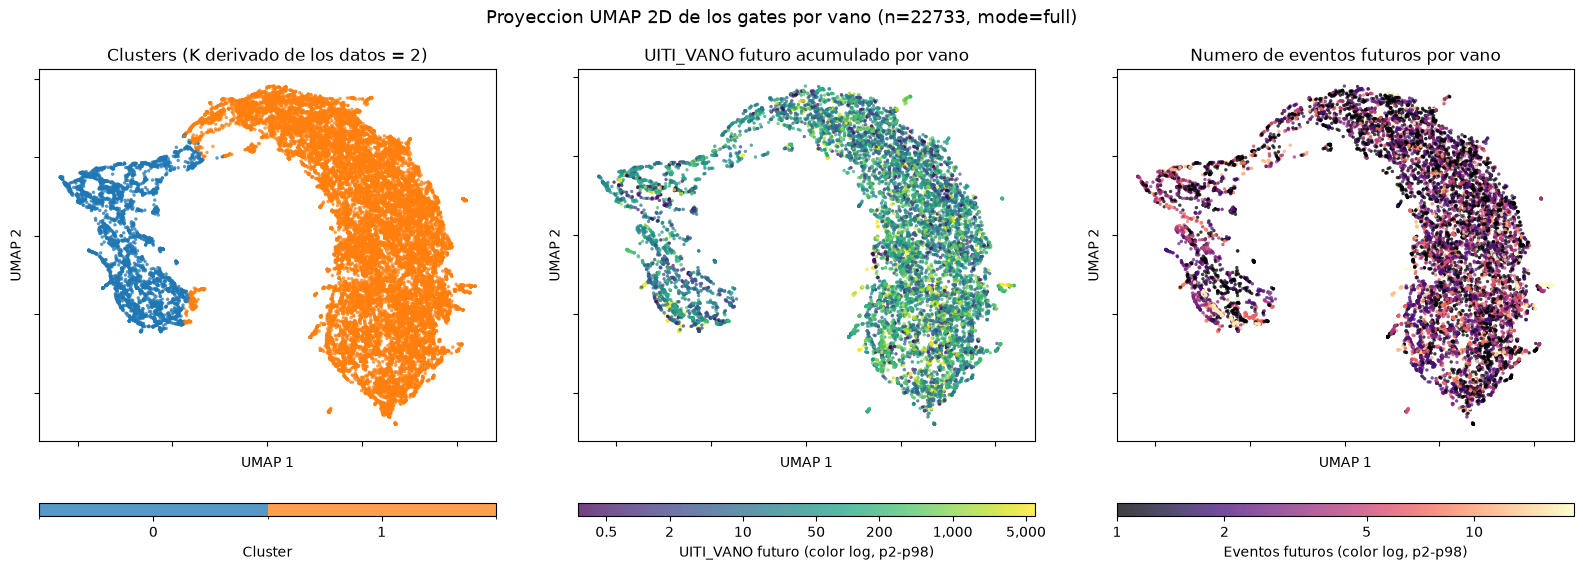

In [19]:
import matplotlib.pyplot as plt
import umap
from matplotlib.colors import BoundaryNorm, ListedColormap


def add_horizontal_colorbar(fig, ax, mappable, label, ticks=None, tick_labels=None):
    # Barra horizontal DEBAJO del panel, posicionada midiendo la extension real ya
    # renderizada -- mismo patron que la libreta 11.
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    to_figure_coords = fig.transFigure.inverted()
    panel_box = ax.get_position()
    panel_bottom = to_figure_coords.transform(ax.get_tightbbox(renderer))[0][1]
    bar_height = 0.022
    bar_y = max(panel_bottom - 0.055 - bar_height, 0.02)
    cax = fig.add_axes([panel_box.x0, bar_y, panel_box.width, bar_height])
    colorbar = fig.colorbar(mappable, cax=cax, orientation="horizontal")
    if ticks is not None:
        colorbar.set_ticks(ticks)
        if tick_labels is not None:
            colorbar.set_ticklabels(tick_labels)
    colorbar.set_label(label)
    return colorbar


def robust_color_limits(values, low=2.0, high=98.0):
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return None, None
    vmin, vmax = np.percentile(finite, [low, high])
    if vmin == vmax:
        return None, None
    return float(vmin), float(vmax)


def log_ticks_in_original_units(log_vmin, log_vmax, max_ticks=8):
    if log_vmin is None or log_vmax is None:
        return None, None
    candidates = sorted(
        {mantissa * (10.0 ** exponent)
         for exponent in range(int(np.floor(log_vmin)), int(np.ceil(log_vmax)) + 1)
         for mantissa in (1, 2, 5)}
    )
    inside = [v for v in candidates if log_vmin <= np.log10(v) <= log_vmax]
    if not inside:
        inside = [10.0 ** log_vmin, 10.0 ** log_vmax]
    if len(inside) > max_ticks:
        inside = inside[:: int(np.ceil(len(inside) / max_ticks))]
    labels = [f"{v:,.0f}" if v >= 1 else f"{v:g}" for v in inside]
    return np.log10(inside), labels


umap_frame = vano_index_gate.copy()
umap_frame["cluster"] = real_labels_reference
umap_frame = umap_frame.merge(future_uiti, on=["CIRCUITO", "FID_VANO"], how="left")
has_aggregates = umap_frame["UITI_VANO_futuro_acumulado"].notna().to_numpy()

n_vanos_gate = gate_means_by_seed[SEEDS_GATE[0]].shape[0]
if n_vanos_gate < 5:
    print(f"Solo {n_vanos_gate} vanos: se omite la proyeccion UMAP (necesita >= 5).")
else:
    reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
    umap_2d = reducer.fit_transform(gate_means_by_seed[SEEDS_GATE[0]])

    cluster_values = umap_frame["cluster"].to_numpy()
    cluster_ids = np.unique(cluster_values)
    point_size = 6.0 if n_vanos_gate > 5000 else 12.0

    fig, axes = plt.subplots(1, 3, figsize=(16.5, 6.0))
    fig.subplots_adjust(left=0.05, right=0.98, bottom=0.26, top=0.88, wspace=0.18)

    cluster_cmap = ListedColormap(plt.get_cmap("tab10").colors[: len(cluster_ids)])
    cluster_norm = BoundaryNorm(np.arange(len(cluster_ids) + 1) - 0.5, len(cluster_ids))
    scatter_clusters = axes[0].scatter(
        umap_2d[:, 0], umap_2d[:, 1], c=cluster_values, cmap=cluster_cmap, norm=cluster_norm,
        s=point_size, alpha=0.75, linewidths=0,
    )
    axes[0].set_title(f"Clusters (K derivado de los datos = {k_raw})")

    uiti_values = umap_frame["UITI_VANO_futuro_acumulado"].to_numpy()
    log_uiti = np.log10(np.clip(np.nan_to_num(uiti_values, nan=1e-6), 1e-6, None))
    uiti_vmin, uiti_vmax = robust_color_limits(log_uiti[has_aggregates])
    scatter_uiti = axes[1].scatter(
        umap_2d[has_aggregates, 0], umap_2d[has_aggregates, 1],
        c=log_uiti[has_aggregates], cmap="viridis", vmin=uiti_vmin, vmax=uiti_vmax,
        s=point_size, alpha=0.75, linewidths=0,
    )
    axes[1].set_title("UITI_VANO futuro acumulado por vano")

    eventos_values = umap_frame["n_eventos_futuro"].to_numpy()
    log_eventos = np.log10(np.clip(np.nan_to_num(eventos_values, nan=1.0), 1.0, None))
    eventos_vmin, eventos_vmax = robust_color_limits(log_eventos[has_aggregates])
    scatter_eventos = axes[2].scatter(
        umap_2d[has_aggregates, 0], umap_2d[has_aggregates, 1],
        c=log_eventos[has_aggregates], cmap="magma", vmin=eventos_vmin, vmax=eventos_vmax,
        s=point_size, alpha=0.75, linewidths=0,
    )
    axes[2].set_title("Numero de eventos futuros por vano")

    for ax in axes:
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        ax.set_xticklabels([])
        ax.set_yticklabels([])

    fig.suptitle(f"Proyeccion UMAP 2D de los gates por vano (n={n_vanos_gate}, mode={mode})", fontsize=13)

    uiti_ticks, uiti_tick_labels = log_ticks_in_original_units(uiti_vmin, uiti_vmax)
    eventos_ticks, eventos_tick_labels = log_ticks_in_original_units(eventos_vmin, eventos_vmax)
    add_horizontal_colorbar(fig, axes[0], scatter_clusters, "Cluster",
                            ticks=cluster_ids, tick_labels=[str(c) for c in cluster_ids])
    add_horizontal_colorbar(fig, axes[1], scatter_uiti, "UITI_VANO futuro (color log, p2-p98)",
                            ticks=uiti_ticks, tick_labels=uiti_tick_labels)
    add_horizontal_colorbar(fig, axes[2], scatter_eventos, "Eventos futuros (color log, p2-p98)",
                            ticks=eventos_ticks, tick_labels=eventos_tick_labels)

    UMAP_FIGURE_PATH = FIGURES_DIR / f"mgcecdl_graphgated_nb12_{mode}_umap_gates.png"
    fig.savefig(UMAP_FIGURE_PATH, dpi=150)
    print("Figura:", UMAP_FIGURE_PATH)
    plt.show()


## 12. Ablacion: con vs. sin `UITI_VANO` reinyectada

Repite el entrenamiento sobre el brazo SIN `UITI_VANO` (`X_past_without_target`,
`edge_index_without`) para aislar cuanto de la asociacion observada es mera
persistencia versus senal aportada por la reinyeccion del target.


In [20]:
ablation_gate_means_by_seed = {}
vano_index_ablation = None
for seed in SEEDS_SEARCH:
    _, gate_means_wo, vano_index_wo = entrenar_y_agrupar(
        features=features_without_target, adjacency=A_without, edge_index=edge_index_without,
        feature_mean=feature_mean_without, feature_std=feature_std_without,
        X_past_arr=X_past_without_target, circuito_arr=circuito_past, fid_vano_arr=fid_vano_past,
        alpha=best_params["alpha"], dropout=best_params["dropout"],
        lambda_reconstruction=best_params["lambda_reconstruction"],
        lambda_mutual_information=best_params["lambda_mutual_information"],
        lambda_gate_deviation=best_params["lambda_gate_deviation"],
        epochs=ABLATION_EPOCHS, seed=seed,
    )
    ablation_gate_means_by_seed[seed] = gate_means_wo
    if vano_index_ablation is None:
        vano_index_ablation = vano_index_wo

k_ablation = k_raw if k_raw > 1 else 2
ablation_labels = KMeans(
    n_clusters=k_ablation, n_init=10, random_state=SEEDS_SEARCH[0]
).fit(ablation_gate_means_by_seed[SEEDS_SEARCH[0]]).labels_
merged_ablation = vano_index_ablation.assign(cluster=ablation_labels).merge(
    future_uiti, on=["CIRCUITO", "FID_VANO"], how="inner"
)
epsilon_sin_uiti_vano = _epsilon_squared_or_none(merged_ablation)

print("Ablacion (sin UITI_VANO reinyectada):")
print(f"  epsilon^2 (sin UITI_VANO)  = {epsilon_sin_uiti_vano}")
print(f"  epsilon^2 (con UITI_VANO)  = {epsilon_gate}")
if epsilon_sin_uiti_vano is not None and epsilon_gate is not None:
    print(f"  delta (con - sin)          = {epsilon_gate - epsilon_sin_uiti_vano:.6f}")


Ablacion (sin UITI_VANO reinyectada):
  epsilon^2 (sin UITI_VANO)  = 0.0002344221111851113
  epsilon^2 (con UITI_VANO)  = 0.012743084778842725
  delta (con - sin)          = 0.012509


## 13. Guardia de proxy univariante

Para CADA feature (incluida `UITI_VANO` explicitamente) se ajusta un
`KMeans` 1-D y se compara su ARI contra los clusters de gates. `max_f ARI >
0.8` invalida (voids) el resultado.


In [21]:
X_vano_means, _ = agrupar_gates_por_vano(X_past_with_target, circuito_past, fid_vano_past)
proxy_guard_table = guardia_proxy_univariante(
    real_labels_reference, X_vano_means, features_with_target,
    k=k_raw if k_raw > 1 else 2, seed=SEEDS_GATE[0],
)
print(proxy_guard_table.head(10))
print("voided:", proxy_guard_table.attrs["voided"], "| max_ari:", proxy_guard_table.attrs["max_ari"])
if "uiti_vano_ari" in proxy_guard_table.attrs:
    print("ARI de UITI_VANO en solitario:", proxy_guard_table.attrs["uiti_vano_ari"])
if proxy_guard_table.attrs["voided"]:
    print("GUARDIA DE PROXY DISPARADA: una sola variable reproduce la agrupacion "
          "(ARI > umbral); el resultado se marca void.")


       feature       ari
0           X2  0.687667
1          DDT  0.677627
2  wind_spd_10  0.227741
3      temp_10  0.213109
4           Y2  0.207470
5  wind_spd_11  0.204885
6      temp_11  0.196379
7       temp_9  0.189943
8   wind_spd_9  0.176217
9       temp_8  0.153224
voided: False | max_ari: 0.6876674358145557
ARI de UITI_VANO en solitario: -0.020548253778044135


## 14. Linea base sin grafo (obligatoria)

`KMeans` sobre la media por vano de las features crudas ESTANDARIZADAS,
usando el mismo protocolo de K y semilla que el brazo con gates -- ya
calculada como parte de la compuerta de aceptacion (criterio 4).


In [22]:
print(f"Linea base sin grafo: K={k_raw if k_raw > 1 else 2} | "
      f"n_vanos={len(baseline_vano_index)} | "
      f"epsilon^2 (baseline) = {epsilon_baseline}")


Linea base sin grafo: K=2 | n_vanos=22733 | epsilon^2 (baseline) = 0.03907463990806298


## 15. K derivado de los datos y vista operativa de 3-4 niveles

`k_raw` nunca se sustituye silenciosamente. La vista de 3-4 niveles es un
paso EXPLICITO y separado que ordena los clusters por criticidad futura
MEDIANA -- solo para reporte, jamas realimentada al entrenamiento ni a la
compuerta de aceptacion.


In [23]:
print(f"K bruto (derivado de los datos, nunca forzado): k_raw={k_raw}")
if k_raw >= 3:
    cluster_median_criticality = (
        merged_gate.groupby("cluster")["UITI_VANO_futuro_acumulado"].median().sort_values()
    )
    ordered_clusters = list(cluster_median_criticality.index)
    n_tiers = 4 if k_raw >= 4 else 3
    tier_bins = np.array_split(ordered_clusters, n_tiers)
    cluster_to_tier = {
        cluster: tier_index
        for tier_index, bin_clusters in enumerate(tier_bins)
        for cluster in bin_clusters
    }
    tier_view = merged_gate.assign(tier=merged_gate["cluster"].map(cluster_to_tier))
    print(f"Vista operativa derivada de {n_tiers} niveles (nunca sustituye a k_raw={k_raw}):")
    print(tier_view.groupby("tier")["UITI_VANO_futuro_acumulado"].agg(["count", "median"]))
else:
    tier_view = None
    print(f"k_raw={k_raw} < 3: se reporta honestamente sin forzar una vista de 3-4 niveles.")


K bruto (derivado de los datos, nunca forzado): k_raw=2
k_raw=2 < 3: se reporta honestamente sin forzar una vista de 3-4 niveles.


## 16. Asociacion cluster vs. criticidad futura (Kruskal-Wallis + epsilon^2 + Dunn-BH)

Reutiliza `asociacion_criticidad` (PR2) -- Kruskal-Wallis, tamano de efecto
`epsilon^2`, y post-hoc de Dunn con correccion Benjamini-Hochberg. No se
reimplementa ninguna de estas pruebas aqui.


In [24]:
if merged_gate["cluster"].nunique() >= 2:
    criticidad_stats = asociacion_criticidad(
        merged_gate["cluster"].to_numpy(), merged_gate["UITI_VANO_futuro_acumulado"].to_numpy()
    )
    print(f"Kruskal-Wallis H={criticidad_stats['H']:.4f} p={criticidad_stats['p_value']:.4g} "
          f"epsilon^2={criticidad_stats['epsilon_squared']:.4f} (n={criticidad_stats['n']}, "
          f"k={criticidad_stats['k']})")
    print(criticidad_stats["pairwise"])
else:
    print("Menos de 2 clusters con datos futuros disponibles: no se evalua Kruskal-Wallis.")


Kruskal-Wallis H=134.9748 p=3.344e-31 epsilon^2=0.0127 (n=10593, k=2)
   cluster_a  cluster_b   n_a   n_b  mean_rank_a  mean_rank_b          z  \
0          0          1  1883  8710  4554.580191  5457.502468 -11.617864   

        p_value    p_value_bh  
0  3.343939e-31  3.343939e-31  


## 17. Diagnostico de persistencia: correlacion de CONTEO de eventos (secundaria)

`UITI_VANO` futuro acumulado es la metrica PRIMARIA (seccion 16). El CONTEO
de eventos es secundario; su correlacion pasado-futuro se reporta junto con
las tres explicaciones candidatas (`diagnostico_persistencia`, diseno D8):
regresion a la media, intervencion de CHEC (por `COD_CAUSA`), y censura.
Se reutiliza `diagnostico_persistencia` sumando una columna unitaria por
evento, de forma que la suma agregada por vano ES el conteo.


In [25]:
df_identidad_evento_unitario = df_identidad.copy()
df_identidad_evento_unitario["EVENTO_UNITARIO"] = 1
diagnostico_eventos = diagnostico_persistencia(
    df_identidad_evento_unitario, past_mask, future_mask, target="EVENTO_UNITARIO",
)

print(f"Correlacion pasado-futuro (CONTEO de eventos, metrica secundaria): "
      f"{diagnostico_eventos['primary_correlation_both_windows']:.4f} "
      f"(n_vanos={diagnostico_eventos['n_vanos_both_windows']})")
print(f"  Explicacion 1 -- regresion a la media (intra-pasado): "
      f"{diagnostico_eventos['regression_to_mean_correlation']:.4f}")
print(f"  Explicacion 2 -- intervencion CHEC por COD_CAUSA:")
print(diagnostico_eventos["intervention_by_cod_causa"])
print(f"  Explicacion 3 -- censura (sin restriccion de presencia en ambas ventanas): "
      f"{diagnostico_eventos['censoring_correlation_unrestricted']:.4f} "
      f"(n_vanos={diagnostico_eventos['n_vanos_unrestricted']})")


Correlacion pasado-futuro (CONTEO de eventos, metrica secundaria): 0.4266 (n_vanos=10593)
  Explicacion 1 -- regresion a la media (intra-pasado): 0.4721
  Explicacion 2 -- intervencion CHEC por COD_CAUSA:
    COD_CAUSA  past_total  future_total    delta
0           4     11682.0        7933.0  -3749.0
1           5      1538.0         416.0  -1122.0
2           6       232.0          85.0   -147.0
3           7       483.0         168.0   -315.0
4           8       369.0         175.0   -194.0
5           9       669.0          14.0   -655.0
6          10      1053.0           0.0  -1053.0
7          11         0.0          21.0     21.0
8          12      5366.0        1106.0  -4260.0
9          14         0.0           8.0      8.0
10         15       674.0         440.0   -234.0
11         16       447.0        1019.0    572.0
12         17        58.0         202.0    144.0
13         20      6674.0        5803.0   -871.0
14         21       175.0           7.0   -168.0
15         

## 18. Limitacion: confusion estacional y techo interpretativo honesto

El dataset abarca `2025-11-01` a `2026-04-30`: la ventana futura de
validacion son apenas ~2 meses de una unica estacion. Esta particion no
puede separar el efecto del TIEMPO del efecto de la ESTACION con solo seis
meses de datos -- cualquier lectura de "mejora futura" o "deterioro futuro"
debe leerse con esta confusion presente, junto a cada resultado de la
ventana futura reportado arriba.

**Techo interpretativo honesto.** El payload fisico del grafo experto es
reducido: unos pocos acoplamientos base, algo mas al incluir las variables
recuperadas por la seleccion nb12-local. Este cuaderno NO reclama haber
recuperado la estructura fisica completa de la red de distribucion -- los
gates aprendidos son, en el mejor de los casos, una re-ponderacion por
muestra sobre un esqueleto de grafo deliberadamente pequeno.


## 19. Resumen final

Se reportan, en una sola tabla, las cantidades que este cuaderno DERIVA en
tiempo de ejecucion (nunca literales): `p`/`E` por brazo, las features de
grado 0, la MI normalizada alcanzada, la varianza de gates frente a
`lambda_dev`, y la fecha de corte p70.


In [26]:
resumen_final = {
    "mode": mode,
    "p_con_uiti_vano": len(features_with_target),
    "E_con_uiti_vano": edge_index_with.n_edges,
    "p_sin_uiti_vano": len(features_without_target),
    "E_sin_uiti_vano": edge_index_without.n_edges,
    "features_grado_cero": ungatable,
    "fecha_corte_p70": str(fecha_corte),
    "tau": tau,
    "k_raw": k_raw,
    "acceptance_criteria": acceptance_criteria,
    "graph_signal": GRAPH_SIGNAL,
    "beats_baseline_sin_grafo": BEATS_BASELINE,
    "final_cluster_source": FINAL_CLUSTER_SOURCE,
    "epsilon_squared_con_uiti_vano": epsilon_gate,
    "epsilon_squared_sin_uiti_vano": epsilon_sin_uiti_vano,
    "epsilon_squared_baseline_sin_grafo": epsilon_baseline,
    "correlacion_conteo_eventos_pasado_futuro": diagnostico_eventos["primary_correlation_both_windows"],
    "proxy_guard_voided": bool(proxy_guard_table.attrs["voided"]),
}
for key, value in resumen_final.items():
    print(f"{key}: {value}")


mode: full
p_con_uiti_vano: 75
E_con_uiti_vano: 73
p_sin_uiti_vano: 74
E_sin_uiti_vano: 71
features_grado_cero: ['FECHA_OPERACION_TRF', 'LONG_CRUCETA']
fecha_corte_p70: 2026-03-11T03:14:44.000000000
tau: 0.1905536937133471
k_raw: 2
acceptance_criteria: {'1_no_colapsado': True, '2_ari_estable': True, '3_supera_control_permutacion': True, '4_supera_baseline_sin_grafo': False}
graph_signal: True
beats_baseline_sin_grafo: False
final_cluster_source: baseline
epsilon_squared_con_uiti_vano: 0.012743084778842725
epsilon_squared_sin_uiti_vano: 0.0002344221111851113
epsilon_squared_baseline_sin_grafo: 0.03907463990806298
correlacion_conteo_eventos_pasado_futuro: 0.4265809343682208
proxy_guard_voided: False


## 20. Caracterizacion de familias de vanos (SOLO descriptiva, NUNCA predictiva)

**Esta seccion caracteriza -- NO es una prediccion.** La corrida completa (ver
`sdd/notebook-12-criticality-representation` apply-progress) mostro que el
ablation con vs. sin `UITI_VANO` reinyectada deja epsilon^2 en 0.0127 con la
variable y en 0.00023 sin ella -- un factor de ~54x, es decir, casi toda la
asociacion aparente entre clusters y `UITI_VANO` futuro es PERSISTENCIA
estadistica, no una senal nueva aprendida por el mecanismo de gates.

Ademas, `UITI` y `UITI_VANO` son ellas mismas features de ENTRADA del modelo
(seccion 1, reinyeccion). Si esta seccion abandonara la particion cronologica
para usar remuestreo/validacion cruzada estratificada -- que es exactamente
lo que hace a continuacion, sobre TODO el conjunto -- cualquier asociacion
entre clusters y UITI acumulada medida SIN separacion temporal seria
circular: la variable ya esta dentro del vector que se agrupa.

Por eso ningun resultado de esta seccion se reporta como poder predictivo.
Todo descriptor de `UITI`/`UITI_VANO` o de conteo de eventos aqui abajo se
marca explicitamente HISTORICO/DESCRIPTIVO. El objetivo es una taxonomia
estable e interpretable de familias de vanos -- no un pronostico.


In [27]:
if mode == "smoke":
    CHAR_K_VALUES = tuple(range(2, 5))
    CHAR_STABILITY_N_REPETICIONES = 3
    CHAR_SEPARABILITY_N_SPLITS = 3
else:
    # Diseno: la curva de estabilidad barre K en 2..8.
    CHAR_K_VALUES = tuple(range(2, 9))
    CHAR_STABILITY_N_REPETICIONES = 20
    CHAR_SEPARABILITY_N_SPLITS = 5
CHAR_STABILITY_FRACCION = 0.8

print(f"mode={mode!r} | CHAR_K_VALUES={CHAR_K_VALUES} | "
      f"CHAR_STABILITY_N_REPETICIONES={CHAR_STABILITY_N_REPETICIONES} | "
      f"CHAR_SEPARABILITY_N_SPLITS={CHAR_SEPARABILITY_N_SPLITS}")


mode='full' | CHAR_K_VALUES=(2, 3, 4, 5, 6, 7, 8) | CHAR_STABILITY_N_REPETICIONES=20 | CHAR_SEPARABILITY_N_SPLITS=5


### 20.1 Estabilidad por submuestreo (el K se elige por consistencia, no por `k_raw`)

`estabilidad_por_submuestreo` mide si una particion sobrevive a remuestreo
independiente -- esa es la definicion operativa de "consistente" en esta
seccion. Se corre sobre CADA semilla de `SEEDS_GATE` (multi-semilla, con
barras de error entre semillas -- MPS no es determinista) para elegir
`K_ESTABLE`, deliberadamente SIN mirar `k_raw` (seccion 15) ni el pedido
original de 3-4 niveles.


In [28]:
stability_by_seed = {}
for seed in SEEDS_GATE:
    stability_by_seed[seed] = estabilidad_por_submuestreo(
        gate_means_by_seed[seed], k_values=CHAR_K_VALUES,
        n_repeticiones=CHAR_STABILITY_N_REPETICIONES, fraccion=CHAR_STABILITY_FRACCION, seed=seed,
    )

stability_curve = {
    k: {
        "mean_ari": float(np.mean([stability_by_seed[s]["mean_ari_by_k"][k] for s in SEEDS_GATE])),
        "std_ari": float(np.std([stability_by_seed[s]["mean_ari_by_k"][k] for s in SEEDS_GATE])),
    }
    for k in CHAR_K_VALUES
}

print("Curva de estabilidad (ARI medio +/- desviacion ENTRE semillas de la compuerta):")
for k, stats in stability_curve.items():
    print(f"  K={k}: ARI={stats['mean_ari']:.4f} +/- {stats['std_ari']:.4f}")

K_ESTABLE = max(stability_curve, key=lambda k: stability_curve[k]["mean_ari"])
print()
print(f"K elegido por estabilidad (NUNCA por k_raw={k_raw}, ni por el pedido original de 3-4): "
      f"K_ESTABLE={K_ESTABLE}")
if not (3 <= K_ESTABLE <= 4):
    print(f"AVISO: el K mas estable ({K_ESTABLE}) NO cae en el rango 3-4 solicitado originalmente "
          "-- se reporta honestamente sin forzarlo.")

char_cluster_labels = KMeans(
    n_clusters=K_ESTABLE, n_init=10, random_state=SEEDS_GATE[0]
).fit(gate_means_by_seed[SEEDS_GATE[0]]).labels_


Curva de estabilidad (ARI medio +/- desviacion ENTRE semillas de la compuerta):
  K=2: ARI=0.9992 +/- 0.0004
  K=3: ARI=0.9600 +/- 0.0643
  K=4: ARI=0.9904 +/- 0.0037
  K=5: ARI=0.9746 +/- 0.0161
  K=6: ARI=0.9689 +/- 0.0160
  K=7: ARI=0.9202 +/- 0.0561
  K=8: ARI=0.9149 +/- 0.0610

K elegido por estabilidad (NUNCA por k_raw=2, ni por el pedido original de 3-4): K_ESTABLE=2
AVISO: el K mas estable (2) NO cae en el rango 3-4 solicitado originalmente -- se reporta honestamente sin forzarlo.


### 20.2 Separabilidad fuera de pliegue (clasificador vs. control de etiquetas barajadas)

`separabilidad_fuera_de_pliegue` entrena un `RandomForestClassifier` por
pliegue estratificado y reporta precision balanceada OUT-OF-FOLD -- si las
familias son estructura real, un clasificador las recupera sin haberlas
visto en entrenamiento. El control de piso barajado (etiquetas
aleatoriamente permutadas) da el nivel de azar esperado (`~1/K_ESTABLE`).
Corrido multi-semilla (`SEEDS_GATE`) con barras de error.


In [29]:
char_edge_names = [f"{source}->{target}" for source, target in edge_index_with.names]

separability_by_seed = {}
shuffled_by_seed = {}
for seed in SEEDS_GATE:
    seed_gate_means = gate_means_by_seed[seed]
    if K_ESTABLE > 1:
        seed_char_labels = KMeans(
            n_clusters=K_ESTABLE, n_init=10, random_state=seed
        ).fit(seed_gate_means).labels_
    else:
        seed_char_labels = np.zeros(seed_gate_means.shape[0], dtype=int)

    cluster_sizes = np.bincount(seed_char_labels)
    min_cluster_size = int(cluster_sizes.min()) if cluster_sizes.size > 0 else 0
    effective_n_splits = min(CHAR_SEPARABILITY_N_SPLITS, min_cluster_size)
    if len(np.unique(seed_char_labels)) < 2 or effective_n_splits < 2:
        print(f"  semilla {seed}: cluster minimo con {min_cluster_size} vano(s) -- "
              "insuficiente para StratifiedKFold, se omite esta semilla.")
        continue

    separability_by_seed[seed] = separabilidad_fuera_de_pliegue(
        seed_gate_means, seed_char_labels, n_splits=effective_n_splits, seed=RANDOM_STATE,
        feature_names=char_edge_names,
    )
    rng_shuffle_seed = np.random.default_rng(seed)
    shuffled_seed_labels = rng_shuffle_seed.permutation(seed_char_labels)
    shuffled_by_seed[seed] = separabilidad_fuera_de_pliegue(
        seed_gate_means, shuffled_seed_labels, n_splits=effective_n_splits, seed=RANDOM_STATE,
    )

if separability_by_seed:
    real_balanced_accuracies = [r["balanced_accuracy"] for r in separability_by_seed.values()]
    shuffled_balanced_accuracies = [r["balanced_accuracy"] for r in shuffled_by_seed.values()]
    print(f"Precision balanceada fuera de pliegue (entre semillas de la compuerta): "
          f"{np.mean(real_balanced_accuracies):.4f} +/- {np.std(real_balanced_accuracies):.4f}")
    print(f"Control de piso (etiquetas barajadas, entre semillas): "
          f"{np.mean(shuffled_balanced_accuracies):.4f} +/- {np.std(shuffled_balanced_accuracies):.4f} "
          f"(esperado ~ 1/K_ESTABLE = {1.0 / K_ESTABLE:.4f})")

    separability_reference = separability_by_seed[SEEDS_GATE[0]]
    print(f"Precision balanceada (semilla de referencia {SEEDS_GATE[0]}): "
          f"{separability_reference['balanced_accuracy']:.4f} "
          f"(por pliegue: {separability_reference['balanced_accuracy_by_fold']})")
    print("Importancias de features (aristas del grafo experto) mas relevantes para distinguir familias:")
    print(separability_reference["feature_importances"].head(10))
else:
    separability_reference = None
    print("Ningun cluster tiene suficientes vanos por clase para StratifiedKFold en ninguna "
          "semilla de la compuerta: se omite la separabilidad fuera de pliegue en esta corrida.")


Precision balanceada fuera de pliegue (entre semillas de la compuerta): 0.9974 +/- 0.0016
Control de piso (etiquetas barajadas, entre semillas): 0.5004 +/- 0.0016 (esperado ~ 1/K_ESTABLE = 0.5000)
Precision balanceada (semilla de referencia 10): 0.9948 (por pliegue: [0.9973014183649047, 0.9953863311147663, 0.991556338484124, 0.9952935699916187, 0.994341649129854])
Importancias de features (aristas del grafo experto) mas relevantes para distinguir familias:
                           feature  importance
0  FECHA_OPERACION_VANO->CONDUCTOR    0.225896
1     PROMEDIO_KWH_VANO->CNT_FASES    0.129817
2                         X2->TIPO    0.123360
3                   temp_6->temp_5    0.099136
4          wind_spd_10->wind_spd_9    0.037336
5                   temp_9->temp_8    0.036714
6                  temp_10->temp_9    0.031900
7                     CNT_VN->TIPO    0.031391
8                   temp_1->temp_0    0.027239
9                   temp_8->temp_7    0.021386


### 20.3 Aristas expertas mas desviadas por familia

Reutiliza `tabla_desviacion_aristas` (seccion 11) sobre `char_cluster_labels`
-- cada familia es describible como "corre mas caliente/frio que la
poblacion" sobre aristas NOMBRADAS del grafo experto.


In [30]:
char_edge_deviation_table = tabla_desviacion_aristas(
    gate_means_by_seed[SEEDS_GATE[0]], edge_index_with, char_cluster_labels, colapsar_familias=True,
)
print("Aristas expertas (o cadenas de familia climatica) que mas se desvian de la poblacion, por familia:")
for cluster in sorted(np.unique(char_cluster_labels)):
    top_rows = char_edge_deviation_table[char_edge_deviation_table["cluster"] == cluster].head(3)
    print(f"Familia {cluster}:")
    print(top_rows[["source", "target", "delta", "abs_delta_rank"]])


Aristas expertas (o cadenas de familia climatica) que mas se desvian de la poblacion, por familia:
Familia 0:
                 source     target     delta  abs_delta_rank
0                    X2       TIPO  0.095063               1
1  FECHA_OPERACION_VANO  CONDUCTOR  0.072169               2
2     PROMEDIO_KWH_VANO  CNT_FASES -0.041748               3
Familia 1:
                  source     target     delta  abs_delta_rank
33                    X2       TIPO -0.017823               1
34  FECHA_OPERACION_VANO  CONDUCTOR -0.013530               2
35     PROMEDIO_KWH_VANO  CNT_FASES  0.007827               3


### 20.4 Perfil por familia (`perfil_por_cluster`) en lenguaje de ingenieria

`perfil_por_cluster` da el efecto ESTANDARIZADO de cada familia frente a la
poblacion, por arista -- se traduce a una frase de ingenieria por familia
usando las 3 aristas de mayor efecto.


In [31]:
char_profile_table = perfil_por_cluster(
    gate_means_by_seed[SEEDS_GATE[0]], char_edge_names, char_cluster_labels,
)

for cluster in sorted(np.unique(char_cluster_labels)):
    top_effects = char_profile_table[char_profile_table["cluster"] == cluster].head(3)
    n_members = int(np.sum(char_cluster_labels == cluster))
    descriptions = []
    for _, row in top_effects.iterrows():
        direction = "mas caliente" if row["efecto_estandarizado"] > 0 else "mas fria"
        descriptions.append(
            f"corre {row['nombre']} {direction} que la poblacion "
            f"(efecto={row['efecto_estandarizado']:.2f})"
        )
    print(f"Familia {cluster} (n={n_members} vanos): " + "; ".join(descriptions))


Familia 0 (n=3589 vanos): corre FECHA_OPERACION_VANO->CONDUCTOR mas caliente que la poblacion (efecto=2.13); corre X2->TIPO mas caliente que la poblacion (efecto=1.79); corre temp_6->temp_5 mas fria que la poblacion (efecto=-1.64)
Familia 1 (n=19144 vanos): corre FECHA_OPERACION_VANO->CONDUCTOR mas fria que la poblacion (efecto=-0.40); corre X2->TIPO mas fria que la poblacion (efecto=-0.34); corre temp_6->temp_5 mas caliente que la poblacion (efecto=0.31)


### 20.5 Perfiles HISTORICOS/DESCRIPTIVOS de `UITI_VANO` y conteo de eventos por familia

Las dos cantidades de abajo (`UITI_VANO_futuro_acumulado`, `n_eventos_futuro`,
seccion 3) se reportan aqui como caracterizacion HISTORICA/DESCRIPTIVA de
cada familia -- NUNCA como una prediccion. Ver la nota de alcance al inicio
de esta seccion (20) para la razon: sin particion cronologica, cualquier
lectura predictiva seria circular.


In [32]:
char_vano_index = vano_index_gate.copy()
char_vano_index["familia"] = char_cluster_labels
char_history = char_vano_index.merge(future_uiti, on=["CIRCUITO", "FID_VANO"], how="left")

print("Perfil HISTORICO/DESCRIPTIVO de UITI_VANO futuro acumulado por familia (NO es una prediccion):")
print(char_history.groupby("familia")["UITI_VANO_futuro_acumulado"].agg(["count", "mean", "median", "std"]))
print()
print("Perfil HISTORICO/DESCRIPTIVO de conteo de eventos futuros por familia (NO es una prediccion):")
print(char_history.groupby("familia")["n_eventos_futuro"].agg(["count", "mean", "median", "std"]))


Perfil HISTORICO/DESCRIPTIVO de UITI_VANO futuro acumulado por familia (NO es una prediccion):
         count        mean     median          std
familia                                           
0         1883  466.823761  27.023191  1805.154755
1         8710  516.872824  55.882440  1423.260970

Perfil HISTORICO/DESCRIPTIVO de conteo de eventos futuros por familia (NO es una prediccion):
         count      mean  median       std
familia                                   
0         1883  4.313861     3.0  4.287460
1         8710  3.671527     2.0  4.274877


## 21. `K_ENTREGA` operativo y anidamiento contra `K_ESTABLE`

`K_ESTABLE` (seccion 20.1) es lo que eligen los DATOS por consistencia.
`K_ENTREGA` es lo que pide la OPERACION: cuatro niveles de riesgo. Son cosas
distintas y el cuaderno no las mezcla ni finge que los datos pidieron cuatro.

La pregunta que decide si esa diferencia importa es de ANIDAMIENTO: cuando
`K_ENTREGA > K_ESTABLE`, la particion de entrega es un refinamiento legitimo
solo si cada familia fina vive dentro de UNA sola familia estable. Si una
familia fina cruza la frontera, el nivel grueso no la representa y la parte
de forma esencialmente arbitraria.

El reporte es POR FAMILIA, nunca un booleano global. Una version previa de
este analisis colapsaba el resultado usando la pureza MINIMA y devolvia un
"no anida" plano para un caso donde tres de cuatro familias eran 100% puras
y una familia pequena (4% de los vanos) quedaba a caballo. Ese booleano
borraba el hallazgo en vez de reportarlo: una familia de frontera es
justamente el argumento a favor de los cuatro niveles, porque muestra el
cohorte que la particion gruesa no puede describir.


In [33]:
# Pedido operativo explicito: cuatro niveles de riesgo.
K_ENTREGA = len(NOMBRES_RIESGO)

labels_estable = KMeans(
    n_clusters=K_ESTABLE, n_init=10, random_state=SEEDS_GATE[0]
).fit(gate_means_by_seed[SEEDS_GATE[0]]).labels_
labels_entrega = KMeans(
    n_clusters=K_ENTREGA, n_init=10, random_state=SEEDS_GATE[0]
).fit(gate_means_by_seed[SEEDS_GATE[0]]).labels_

print(f"K_ESTABLE (elegido por los datos)   = {K_ESTABLE}")
print(f"K_ENTREGA (pedido por la operacion) = {K_ENTREGA}")
print(f"  ARI de estabilidad en K_ESTABLE  = {stability_curve[K_ESTABLE]['mean_ari']:.4f}")
if K_ENTREGA in stability_curve:
    print(f"  ARI de estabilidad en K_ENTREGA  = {stability_curve[K_ENTREGA]['mean_ari']:.4f}")
print()

nesting_table = anidamiento_entre_particiones(labels_entrega, labels_estable)
print("Anidamiento de cada familia de entrega dentro de las familias estables:")
print(nesting_table.to_string(index=False))
print()
print(f"  pureza minima          = {nesting_table.attrs['pureza_minima']:.4f}")
print(f"  pureza media           = {nesting_table.attrs['pureza_media']:.4f}")
print(f"  ARI(K_ESTABLE, K_ENTREGA) = {nesting_table.attrs['ari']:.4f}")
print(f"  fraccion de vanos en familias que SI anidan = "
      f"{nesting_table.attrs['fraccion_vanos_anidados']:.4f}")
print()

familias_que_anidan = nesting_table[nesting_table["anida"]]
familias_frontera = nesting_table[~nesting_table["anida"]]
print(f"LECTURA (por afirmacion, no por booleano unico):")
print(f"  - {len(familias_que_anidan)} de {len(nesting_table)} familias de entrega anidan "
      f"limpiamente y cubren el {100 * nesting_table.attrs['fraccion_vanos_anidados']:.1f}% de los vanos: "
      "para esos, K_ENTREGA es un refinamiento de K_ESTABLE y se puede colapsar sin contradiccion.")
if len(familias_frontera) > 0:
    n_frontera = int(familias_frontera["n_vanos"].sum())
    print(f"  - {len(familias_frontera)} familia(s) de FRONTERA ({n_frontera} vanos, "
          f"{100 * n_frontera / len(labels_entrega):.1f}%) cruzan el limite de K_ESTABLE. "
          "No es ruido: es un cohorte que la particion gruesa no puede representar y "
          "por eso lo reparte de forma arbitraria. Es el argumento operativo a favor "
          "de entregar K_ENTREGA niveles en vez de K_ESTABLE.")
else:
    print("  - Ninguna familia de frontera: el anidamiento es completo.")


K_ESTABLE (elegido por los datos)   = 2
K_ENTREGA (pedido por la operacion) = 4
  ARI de estabilidad en K_ESTABLE  = 0.9992
  ARI de estabilidad en K_ENTREGA  = 0.9904

Anidamiento de cada familia de entrega dentro de las familias estables:
 familia_fina  n_vanos  familia_gruesa_dominante   pureza  anida
            0     7305                         1 0.983847  False
            1     1615                         0 1.000000   True
            2    11845                         1 1.000000   True
            3     1968                         0 0.943089  False

  pureza minima          = 0.9431
  pureza media           = 0.9817
  ARI(K_ESTABLE, K_ENTREGA) = 0.3578
  fraccion de vanos en familias que SI anidan = 0.5921

LECTURA (por afirmacion, no por booleano unico):
  - 2 de 4 familias de entrega anidan limpiamente y cubren el 59.2% de los vanos: para esos, K_ENTREGA es un refinamiento de K_ESTABLE y se puede colapsar sin contradiccion.
  - 2 familia(s) de FRONTERA (9273 vanos, 40.8%) 

## 22. Reajuste final con TODOS los datos (modelo de entrega)

Todo lo anterior se valido sobre la ventana PASADA, reservando la ventana
FUTURA como objetivo independiente. Esa fue la evidencia. El modelo que se
ENTREGA se reajusta sobre el conjunto completo (`X_with_target`, pasado +
futuro) porque en produccion no hay razon para tirar el 30% mas reciente de
la historia.

ALCANCE, dicho sin ambiguedad: a partir de aqui el modelo YA VIO la ventana
futura. Por eso los perfiles de `UITI_VANO` de las secciones 23-25 son
CARACTERIZACION DESCRIPTIVA de los grupos, no validacion fuera de muestra.
La validacion fuera de muestra es la de las secciones 10-19 y no se
re-litiga aqui. Confundir ambas seria circular.


In [34]:
circuito_all = df_identidad["CIRCUITO"].to_numpy()
fid_vano_all = df_identidad["FID_VANO"].to_numpy()

feature_mean_all, feature_std_all = calcular_estadisticas_reconstruccion_mgcecdl(X_with_target)

refit_start = time.perf_counter()
final_result, gate_means_final, vano_index_final = entrenar_y_agrupar(
    features=features_with_target, adjacency=A_with, edge_index=edge_index_with,
    feature_mean=feature_mean_all, feature_std=feature_std_all,
    X_past_arr=X_with_target, circuito_arr=circuito_all, fid_vano_arr=fid_vano_all,
    alpha=best_params["alpha"], dropout=best_params["dropout"],
    lambda_reconstruction=best_params["lambda_reconstruction"],
    lambda_mutual_information=best_params["lambda_mutual_information"],
    lambda_gate_deviation=best_params["lambda_gate_deviation"],
    epochs=GATE_EPOCHS, seed=SEEDS_GATE[0], lr=best_params["lr"],
    weight_decay=best_params["weight_decay"], optimizer_name=best_params["optimizer_name"],
)
final_model = final_result["model"]

print(f"Reajuste final sobre TODAS las filas: {X_with_target.shape[0]} eventos, "
      f"{gate_means_final.shape[0]} vanos, {gate_means_final.shape[1]} aristas.")
print(f"Duracion del reajuste: {format_duration(time.perf_counter() - refit_start)}")
print(f"Perdida de reconstruccion cruda final: {final_result['reconstruction_loss_raw']:.6f} "
      f"(tau = {tau:.6f})")

final_kmeans = KMeans(n_clusters=K_ENTREGA, n_init=10, random_state=SEEDS_GATE[0]).fit(gate_means_final)
labels_final_raw = final_kmeans.labels_
print("Tamano de cada grupo antes de renombrar por riesgo:",
      dict(zip(*np.unique(labels_final_raw, return_counts=True))))


Reajuste final sobre TODAS las filas: 159470 eventos, 27390 vanos, 73 aristas.
Duracion del reajuste: 01:03
Perdida de reconstruccion cruda final: 0.100383 (tau = 0.190554)
Tamano de cada grupo antes de renombrar por riesgo: {np.int32(0): np.int64(15242), np.int32(1): np.int64(2231), np.int32(2): np.int64(1833), np.int32(3): np.int64(8084)}


## 23. Nombres de riesgo por `UITI_VANO` medio, y guardado del modelo

Los ids que devuelve `KMeans` son arbitrarios: el grupo 0 de una corrida no
tiene nada que ver con el grupo 0 de otra. `asignar_nombres_de_riesgo`
reordena los grupos por `UITI_VANO` acumulado ascendente, de modo que el id
pasa a ser ordinal y significa algo: 0 = Bajo, ..., 3 = Alto.

La clave de ordenamiento es la MEDIANA, no la media, y la diferencia no es
cosmetica. `UITI_VANO` acumulado es de cola muy pesada: la media de un grupo
corre varias veces su propia mediana, asi que ordenar por media ordena las
familias por quien sufrio el peor evento y no por quien es persistentemente
critico. La corrida completa anterior, ordenada por media, dejo los tres
niveles inferiores dentro del 6.5% entre si mientras la mediana los ordenaba
al reves -- prueba directa de que la media no soportaba la afirmacion
ordinal. La seccion 23.1 verifica que el orden nuevo si la soporte.

El acumulado se toma aqui sobre TODAS las filas (no solo la ventana futura),
coherente con el modelo de entrega de la seccion 22.

El checkpoint guarda pesos, features, adyacencia, indice de aristas,
hiperparametros, centroides de KMeans y el mapeo de nombres de riesgo, de
modo que otro cuaderno pueda cargarlo y asignar el nivel de riesgo de un
vano nuevo sin repetir nada de este cuaderno.


In [35]:
todas_las_filas = np.ones(len(df_identidad), dtype=bool)
uiti_acumulado = uiti_futuro_por_vano(df_identidad, todas_las_filas).rename(
    columns={
        "UITI_VANO_futuro_acumulado": "UITI_VANO_acumulado",
        "n_eventos_futuro": "n_eventos",
    }
)

# Merge LEFT sobre el indice de vanos para conservar el orden fila-a-fila de
# `gate_means_final`: un merge interno reordenaria y desalinearia las etiquetas.
perfil_vanos = vano_index_final.merge(uiti_acumulado, on=["CIRCUITO", "FID_VANO"], how="left")
assert len(perfil_vanos) == len(labels_final_raw), (
    "el merge de identidad cambio el numero de filas: las etiquetas quedarian desalineadas."
)

riesgo = asignar_nombres_de_riesgo(
    labels_final_raw,
    perfil_vanos["UITI_VANO_acumulado"].to_numpy(),
    nombres=NOMBRES_RIESGO,
    estadistico=ESTADISTICO_DE_RIESGO,
)
labels_final = riesgo["labels"]
nombres_por_grupo = riesgo["nombres"]
perfil_vanos["grupo"] = labels_final
perfil_vanos["riesgo"] = [nombres_por_grupo[g] for g in labels_final]

print(f"Grupos renombrados por UITI_VANO acumulado ({ESTADISTICO_DE_RIESGO}, ascendente):")
print(riesgo["resumen"].to_string(index=False))
print()
print("Mapeo de ids crudos de KMeans -> id ordinal de riesgo:", riesgo["mapeo"])


Grupos renombrados por UITI_VANO acumulado (mediana, ascendente):
 grupo     nombre  n_vanos  uiti_media  uiti_mediana
     0       Bajo     2231  569.231668     65.394932
     1      Medio     8084  565.255572    125.384406
     2 Medio-Alto     1833  534.614670    130.367000
     3       Alto    15242  711.046010    148.176275

Mapeo de ids crudos de KMeans -> id ordinal de riesgo: {1: 0, 3: 1, 2: 2, 0: 3}


### 23.1 El orden entregado se VERIFICA, no se asume

Nombrar los niveles `Bajo..Alto` es una afirmacion ordinal sobre criticidad.
Esa afirmacion la produjo UNA estadistica (la mediana de `UITI_VANO`
acumulado). Si el orden solo existe bajo esa estadistica y se cae bajo la
media o bajo el numero de eventos, entonces el vocabulario es un artefacto
de la clave de ordenamiento y no una propiedad de las familias -- y quien
actue sobre el estaria priorizando mal.

`verificar_orden_de_riesgo` contrasta el orden entregado contra tres
criterios independientes y marca `monotono` cuando el criterio COINCIDE en
que los niveles estan ordenados. Un solo criterio disidente hunde el
veredicto global, a proposito.

Esto no es hipotetico: en la corrida completa anterior, ordenada por MEDIA,
los tres niveles inferiores quedaron dentro del 6.5% entre si, la mediana
los ordenaba al reves y el conteo de eventos ponia `Bajo` por encima de
`Alto`. Por eso el orden ahora se calcula por mediana y se somete a esta
verificacion antes de guardar nada.


In [36]:
verificacion_orden = verificar_orden_de_riesgo(
    labels_final,
    {
        "UITI acumulado (mediana)": (perfil_vanos["UITI_VANO_acumulado"].to_numpy(), "mediana"),
        "UITI acumulado (media)": (perfil_vanos["UITI_VANO_acumulado"].to_numpy(), "media"),
        "numero de eventos (mediana)": (perfil_vanos["n_eventos"].to_numpy(), "mediana"),
    },
)
# Un criterio constante no contradice el orden, pero tampoco lo respalda: contarlo
# como apoyo inflaria la evidencia. Se exige que los tres COINCIDAN y que los tres
# aporten informacion.
ORDEN_VERIFICADO = bool(
    verificacion_orden.attrs["todos_monotonos"]
    and not verificacion_orden.attrs["criterios_sin_informacion"]
)

print("Verificacion del orden de riesgo entregado, criterio por criterio:")
for _, fila in verificacion_orden.iterrows():
    if not fila["informativo"]:
        marca = "SIN INFO"
    elif fila["monotono"]:
        marca = "COINCIDE"
    else:
        marca = "CONTRADICE"
    valores = ", ".join(f"{v:.2f}" for v in fila["valores_por_grupo"])
    print(f"  [{marca:>10}] {fila['criterio']:<28} valores por nivel = [{valores}]")
    print(f"               orden inducido = {fila['orden_inducido']}  "
          f"kendall_tau = {fila['kendall_tau']:.4f}")
print()

if ORDEN_VERIFICADO:
    print("VEREDICTO DEL ORDEN: los tres criterios coinciden en que los niveles estan "
          "ordenados. El vocabulario Bajo..Alto es una propiedad de las familias, no de "
          "la clave de ordenamiento, y se puede entregar como estratificacion.")
else:
    disidentes = verificacion_orden.attrs["criterios_disidentes"]
    sin_info = verificacion_orden.attrs["criterios_sin_informacion"]
    print(f"VEREDICTO DEL ORDEN: NO se sostiene. Criterio(s) que contradicen el orden: "
          f"{disidentes}. Criterio(s) sin informacion (constantes entre niveles, no "
          f"respaldan nada): {sin_info}.")
    print("Lectura honesta: el orden existe bajo la clave con la que se construyo, pero no "
          "sobrevive a los demas criterios, asi que los nombres NO describen una "
          "estratificacion de criticidad. Se reportan igual, marcados como no verificados, "
          "en vez de presentarlos como niveles accionables.")

# Tamano de cada nivel: una estratificacion donde un nivel concentra a la mayoria
# de la flota no es accionable aunque el orden se sostenga.
_tamanos = riesgo["resumen"].set_index("nombre")["n_vanos"]
_fraccion_mayor = float(_tamanos.max()) / float(_tamanos.sum())
print()
print("Tamano por nivel:", {k: int(v) for k, v in _tamanos.items()})
print(f"  el nivel mas grande concentra el {100 * _fraccion_mayor:.1f}% de los vanos")
if _fraccion_mayor > 0.5:
    print("  AVISO: un solo nivel concentra mas de la mitad de la flota -- aunque el orden "
          "se sostenga, eso estratifica poco en la practica.")


Verificacion del orden de riesgo entregado, criterio por criterio:
  [  COINCIDE] UITI acumulado (mediana)     valores por nivel = [65.39, 125.38, 130.37, 148.18]
               orden inducido = (0, 1, 2, 3)  kendall_tau = 1.0000
  [CONTRADICE] UITI acumulado (media)       valores por nivel = [569.23, 565.26, 534.61, 711.05]
               orden inducido = (2, 1, 0, 3)  kendall_tau = 0.0000
  [CONTRADICE] numero de eventos (mediana)  valores por nivel = [3.00, 2.00, 4.00, 3.00]
               orden inducido = (1, 0, 3, 2)  kendall_tau = 0.1826

VEREDICTO DEL ORDEN: NO se sostiene. Criterio(s) que contradicen el orden: ('UITI acumulado (media)', 'numero de eventos (mediana)'). Criterio(s) sin informacion (constantes entre niveles, no respaldan nada): ().
Lectura honesta: el orden existe bajo la clave con la que se construyo, pero no sobrevive a los demas criterios, asi que los nombres NO describen una estratificacion de criticidad. Se reportan igual, marcados como no verificados, en vez

### 23.2 Guardado del modelo de entrega

El checkpoint guarda pesos, features, adyacencia, indice de aristas,
hiperparametros, centroides de KMeans YA REORDENADOS por riesgo, el mapeo de
nombres y el resultado de la verificacion de orden -- de modo que otro
cuaderno pueda cargarlo, asignar el nivel de un vano nuevo, y saber si ese
nivel esta verificado o no, sin repetir nada de este cuaderno.


In [37]:
# El centroide tambien se reordena, para que el checkpoint asigne el mismo
# nivel de riesgo que este cuaderno al aplicarse en otro lado.
centroides_ordenados = np.zeros_like(final_kmeans.cluster_centers_)
for crudo, nuevo in riesgo["mapeo"].items():
    centroides_ordenados[nuevo] = final_kmeans.cluster_centers_[crudo]

MODEL_PATH = MODELS_DIR / f"mgcecdl_graphgated_nb12_{mode}.pt"
guardar_modelo_gated(
    MODEL_PATH,
    final_model,
    features=features_with_target,
    configuracion={
        "modality_feature_indices": construir_modalidades_mgcecdl(list(features_with_target)),
        "hidden_dim": FIXED_HIDDEN_DIM,
        "embed_dim": FIXED_EMBED_DIM,
        "dropout": best_params["dropout"],
    },
    metadata={
        "mode": mode,
        "fecha_corte_validacion": str(fecha_corte),
        "entrenado_sobre": "todas las filas (pasado + futuro)",
        "n_eventos": int(X_with_target.shape[0]),
        "n_vanos": int(gate_means_final.shape[0]),
        "best_params": best_params,
        "epochs": GATE_EPOCHS,
        "seed": SEEDS_GATE[0],
        "K_ENTREGA": K_ENTREGA,
        "K_ESTABLE": K_ESTABLE,
        "nombres_riesgo": nombres_por_grupo,
        "estadistico_de_riesgo": ESTADISTICO_DE_RIESGO,
        "orden_verificado": ORDEN_VERIFICADO,
        "criterios_disidentes": list(verificacion_orden.attrs["criterios_disidentes"]),
        "centroides_kmeans": centroides_ordenados,
        "feature_mean": feature_mean_all,
        "feature_std": feature_std_all,
        "reconstruction_normalization": RECONSTRUCTION_NORMALIZATION,
    },
)
print()
print("Modelo de entrega guardado en:", MODEL_PATH)

# Prueba de humo del checkpoint: se recarga y se exige que reproduzca los mismos gates.
_reloaded = cargar_modelo_gated(MODEL_PATH, device=DEVICE)
with torch.no_grad():
    _probe = torch.as_tensor(X_with_target[:8], dtype=torch.float32).to(DEVICE)
    _gates_original = final_model(_probe)["edge_gates"].cpu().numpy()
    _gates_recargado = _reloaded["model"](_probe)["edge_gates"].cpu().numpy()
assert np.allclose(_gates_original, _gates_recargado, atol=1e-6), (
    "el checkpoint recargado no reproduce los gates del modelo entrenado."
)
print("Verificacion de ida y vuelta del checkpoint: los gates recargados coinciden.")



Modelo de entrega guardado en: /Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/data/models/mgcecdl_graphgated_nb12_full.pt
Verificacion de ida y vuelta del checkpoint: los gates recargados coinciden.


## 24. Grafo reconstruido por grupo y afinidades

Cada vano tiene su propio grafo reconstruido: la arista `(i, j)` del grafo
experto vale `gate * peso_fijo`, con `gate` en (0, 2). Un gate de 1.0
significa "esta arista queda exactamente como la dicta el grafo experto";
por debajo de 1 el grupo ATENUA esa relacion fisica, por encima la AMPLIFICA.
El grafo de un GRUPO es el promedio de los grafos de sus vanos.

Se reportan TRES afinidades, en orden creciente de poder discriminante. La
diferencia entre ellas es justamente el punto:

- **Coseno sobre pesos**: quedara muy cerca de 1.0 para todos los pares. Eso
  NO significa que los grupos sean iguales; es aritmetica. Todo grafo
  reconstruido es `gate * peso_fijo` con gates centrados cerca de 1, asi que
  todos comparten la misma escala dominante del grafo fijo.
- **Correlacion sobre pesos** (Pearson sobre las aristas): quita el nivel
  medio compartido, pero NO quita el perfil de magnitudes del grafo experto.
  Cuando los pesos fijos abarcan un rango amplio (aqui: cadenas climaticas a
  0.90 junto a acoplamientos a 1.0), esa rampa sobrevive al centrado y la
  correlacion tambien se satura cerca de 1. Se reporta igual, para que se vea
  que se satura en vez de afirmar que discrimina.
- **Correlacion sobre la DESVIACION del gate** (`gate_medio - 1.0`): esta es
  la senal propia de cada grupo, con el grafo experto restado. Es la unica de
  las tres que no arranca saturada. No incluye una fila `FIJO` porque la
  desviacion del grafo fijo es cero por definicion y correlacionar contra el
  vector nulo no esta definido.

Leer solo el coseno seria concluir "los cuatro grupos son identicos" cuando
lo que dice es "los cuatro respetan el grafo experto", que es otra cosa.

Sobre la figura: los tres paneles NO comparten escala de color. Cada uno
declara la suya en su titulo, tomada del rango fuera de la diagonal. Una
escala comun `[-1, 1]` seria comparable entre paneles, pero las tres
matrices viven entre ~0.96 y 1.0, asi que el eje compartido las pinta de un
rojo plano y esconde exactamente la estructura que la figura debe mostrar.
La consecuencia hay que tenerla presente al leer: los COLORES no son
comparables entre paneles; lo comparable son los rangos declarados y los
numeros anotados.


In [38]:
grafos_por_grupo = grafo_reconstruido_por_grupo(
    gate_means_final, edge_index_with, labels_final, n_features=len(features_with_target),
)
edge_weights_por_grupo = {g: info["edge_weights"] for g, info in grafos_por_grupo.items()}
edge_weights_fijo = np.asarray(edge_index_with.weights, dtype=np.float64)

afinidad_coseno = afinidad_entre_grafos(edge_weights_por_grupo, edge_weights_fijo, metrica="coseno")
afinidad_correlacion = afinidad_entre_grafos(
    edge_weights_por_grupo, edge_weights_fijo, metrica="correlacion"
)

etiquetas_grupo = {g: f"{g} {nombres_por_grupo[g]}" for g in grafos_por_grupo}
renombrar = {"FIJO": "FIJO", **{str(g): etiquetas_grupo[g] for g in grafos_por_grupo}}
afinidad_coseno = afinidad_coseno.rename(index=renombrar, columns=renombrar)
afinidad_correlacion = afinidad_correlacion.rename(index=renombrar, columns=renombrar)

print("Gate medio por grupo (1.0 = arista igual al grafo experto):")
for g, info in grafos_por_grupo.items():
    gm = info["gate_mean"]
    print(f"  {g} {nombres_por_grupo[g]:<11} n={info['n_vanos']:6d}  "
          f"gate medio={gm.mean():.4f}  min={gm.min():.4f}  max={gm.max():.4f}  "
          f"aristas atenuadas (<1)={int((gm < 1.0).sum())}/{gm.size}")
print()
# Tercera vista: la desviacion del gate respecto a 1.0, es decir la senal
# propia del grupo con el grafo experto restado. Sin fila FIJO: su desviacion
# es cero por definicion y la correlacion contra el vector nulo no existe.
grupos_ordenados = sorted(grafos_por_grupo)
desviaciones = np.vstack([grafos_por_grupo[g]["gate_mean"] - 1.0 for g in grupos_ordenados])
afinidad_desviacion = pd.DataFrame(
    np.corrcoef(desviaciones),
    index=[etiquetas_grupo[g] for g in grupos_ordenados],
    columns=[etiquetas_grupo[g] for g in grupos_ordenados],
)

print("Afinidad COSENO sobre pesos (cerca de 1 por construccion -- no discrimina):")
print(afinidad_coseno.round(6).to_string())
print()
print("Afinidad CORRELACION sobre pesos (quita el nivel medio, no el perfil del grafo experto):")
print(afinidad_correlacion.round(4).to_string())
print()
print("Afinidad CORRELACION sobre la DESVIACION del gate (senal propia de cada grupo):")
print(afinidad_desviacion.round(4).to_string())
print()
_fuera_diagonal = afinidad_desviacion.to_numpy()[~np.eye(len(grupos_ordenados), dtype=bool)]
print(f"  rango fuera de la diagonal: [{_fuera_diagonal.min():.4f}, {_fuera_diagonal.max():.4f}]")
print("  Cuanto mas lejos de 1 este ese rango, mas distinta es la forma en que cada grupo "
      "usa el grafo experto. Si tambien saliera saturado, la lectura honesta seria que los "
      "grupos se separan por INTENSIDAD y no por que aristas privilegian.")


Gate medio por grupo (1.0 = arista igual al grafo experto):
  0 Bajo        n=  2231  gate medio=1.0013  min=0.9278  max=1.1275  aristas atenuadas (<1)=38/73
  1 Medio       n=  8084  gate medio=0.9997  min=0.9713  max=1.0149  aristas atenuadas (<1)=42/73
  2 Medio-Alto  n=  1833  gate medio=1.0017  min=0.9720  max=1.1995  aristas atenuadas (<1)=42/73
  3 Alto        n= 15242  gate medio=0.9994  min=0.9807  max=1.0016  aristas atenuadas (<1)=38/73

Afinidad COSENO sobre pesos (cerca de 1 por construccion -- no discrimina):
                  FIJO    0 Bajo   1 Medio  2 Medio-Alto    3 Alto
FIJO          1.000000  0.999856  0.999991      0.999730  0.999997
0 Bajo        0.999856  1.000000  0.999847      0.999923  0.999821
1 Medio       0.999991  0.999847  1.000000      0.999770  0.999987
2 Medio-Alto  0.999730  0.999923  0.999770      1.000000  0.999682
3 Alto        0.999997  0.999821  0.999987      0.999682  1.000000

Afinidad CORRELACION sobre pesos (quita el nivel medio, no el perfil

Figura: /Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/reports/interpretability/figures/mgcecdl_graphgated_nb12_full_grafos_por_grupo.png


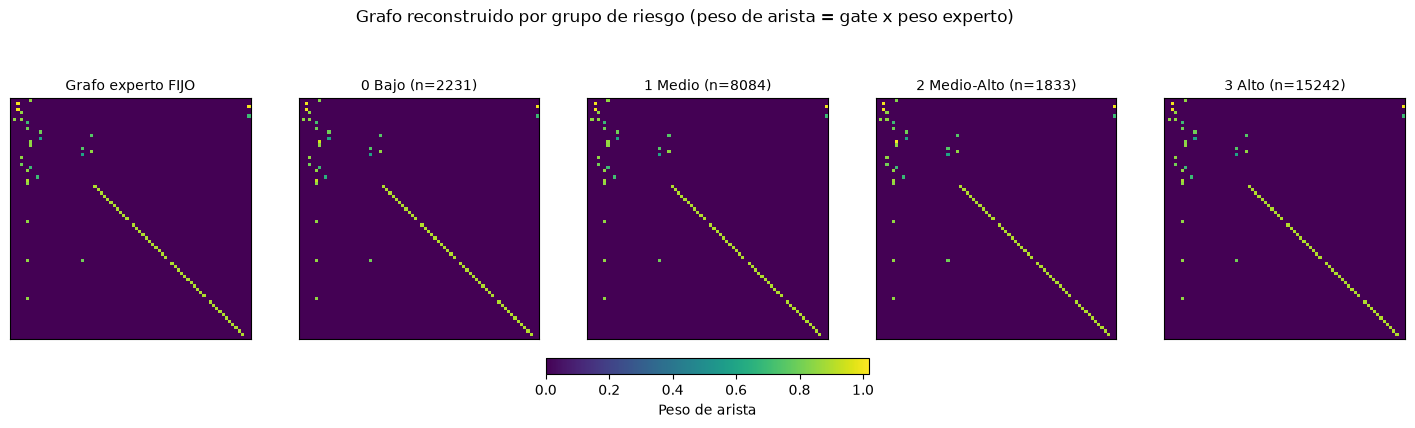

Figura: /Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/reports/interpretability/figures/mgcecdl_graphgated_nb12_full_afinidad_grafos.png


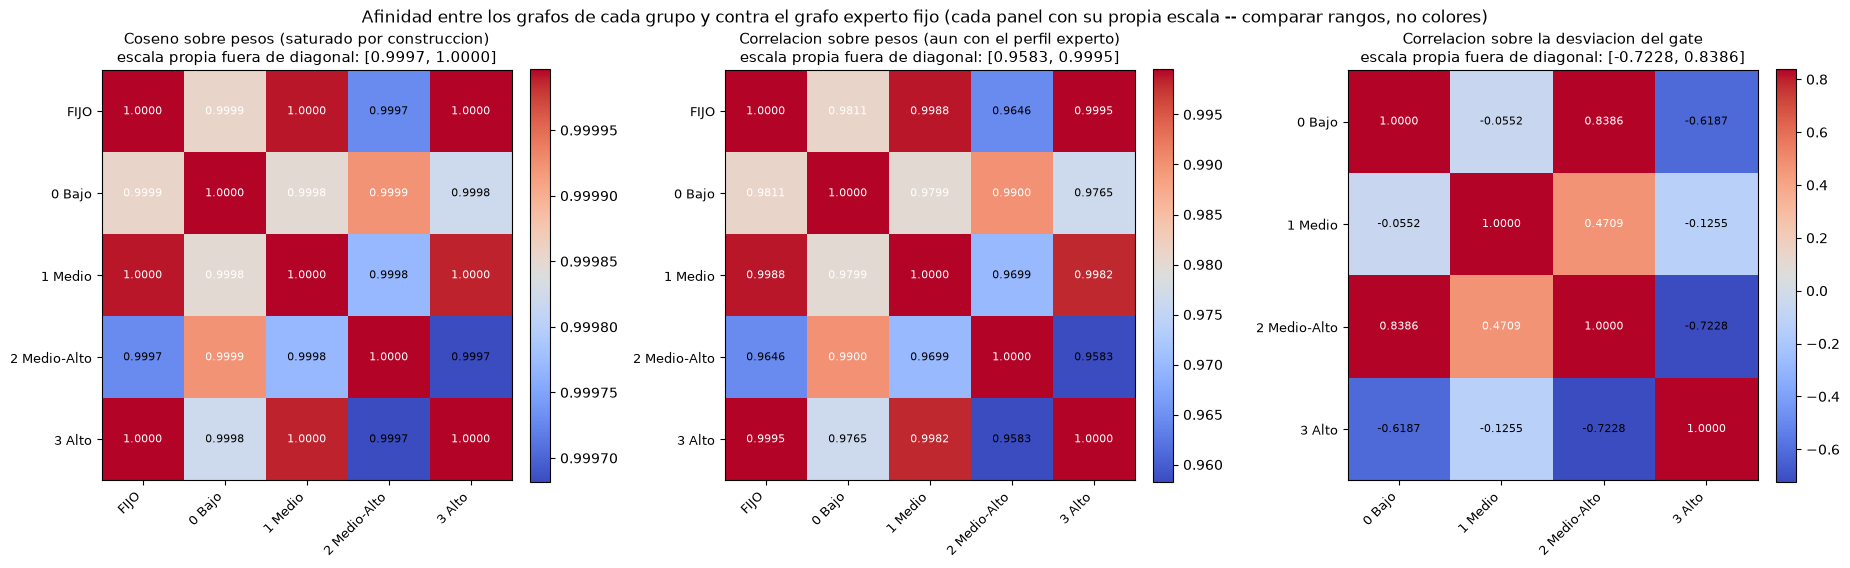

In [39]:
import matplotlib.pyplot as plt

n_paneles = len(grafos_por_grupo) + 1
fig, axes = plt.subplots(1, n_paneles, figsize=(3.6 * n_paneles, 4.2))
matriz_fija = np.zeros((len(features_with_target), len(features_with_target)))
for (fila, columna), peso in zip(edge_index_with.pairs, edge_index_with.weights):
    matriz_fija[fila, columna] = peso

vmax_grafos = max(
    [matriz_fija.max()] + [info["matrix"].max() for info in grafos_por_grupo.values()]
)
im = axes[0].imshow(matriz_fija, cmap="viridis", vmin=0.0, vmax=vmax_grafos, interpolation="nearest")
axes[0].set_title("Grafo experto FIJO", fontsize=10)
for eje_idx, (g, info) in enumerate(grafos_por_grupo.items(), start=1):
    im = axes[eje_idx].imshow(
        info["matrix"], cmap="viridis", vmin=0.0, vmax=vmax_grafos, interpolation="nearest"
    )
    axes[eje_idx].set_title(f"{g} {nombres_por_grupo[g]} (n={info['n_vanos']})", fontsize=10)
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle(
    "Grafo reconstruido por grupo de riesgo (peso de arista = gate x peso experto)", fontsize=12
)
fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.05, pad=0.06, label="Peso de arista")
GRAPHS_FIGURE_PATH = FIGURES_DIR / f"mgcecdl_graphgated_nb12_{mode}_grafos_por_grupo.png"
fig.savefig(GRAPHS_FIGURE_PATH, dpi=150, bbox_inches="tight")
print("Figura:", GRAPHS_FIGURE_PATH)
plt.show()


paneles_afinidad = [
    (afinidad_coseno, "Coseno sobre pesos (saturado por construccion)"),
    (afinidad_correlacion, "Correlacion sobre pesos (aun con el perfil experto)"),
    (afinidad_desviacion, "Correlacion sobre la desviacion del gate"),
]
fig, axes = plt.subplots(1, len(paneles_afinidad), figsize=(6.2 * len(paneles_afinidad), 5.6))
for ax, (frame, titulo) in zip(axes, paneles_afinidad):
    valores = frame.to_numpy(dtype=float)
    # Cada panel lleva su PROPIA escala, tomada del rango FUERA de la diagonal, y la
    # declara en el titulo. Una escala compartida [-1, 1] seria comparable entre
    # paneles pero pinta los tres de un rojo plano: las tres matrices viven entre
    # 0.96 y 1.0, asi que el eje comun esconde justamente la estructura que el
    # panel existe para mostrar. Se comparan los RANGOS declarados, no los colores.
    fuera_diagonal = valores[~np.eye(valores.shape[0], dtype=bool)]
    escala_min, escala_max = float(fuera_diagonal.min()), float(fuera_diagonal.max())
    if np.isclose(escala_min, escala_max):
        escala_min, escala_max = escala_min - 1e-6, escala_max + 1e-6
    imagen = ax.imshow(valores, cmap="coolwarm", vmin=escala_min, vmax=escala_max)
    titulo = f"{titulo}\nescala propia fuera de diagonal: [{escala_min:.4f}, {escala_max:.4f}]"
    ax.set_xticks(range(len(frame.columns)))
    ax.set_yticks(range(len(frame.index)))
    ax.set_xticklabels(frame.columns, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(frame.index, fontsize=9)
    ax.set_title(titulo, fontsize=11)
    for i in range(valores.shape[0]):
        for j in range(valores.shape[1]):
            # Cuatro decimales: con tres, todo lo que pasa entre 0.999 y 1.0 se
            # imprime igual y la tabla dejaria de distinguir lo que el panel muestra.
            centro = 0.5 * (escala_min + escala_max)
            ax.text(j, i, f"{valores[i, j]:.4f}", ha="center", va="center", fontsize=8,
                    color="white" if valores[i, j] >= centro else "black")
    barra = fig.colorbar(imagen, ax=ax, fraction=0.046, pad=0.04)
    # Sin offset cientifico: con un rango como [0.9999, 1.0000] matplotlib factoriza
    # un "+9.999e-1" que se dibuja encima del titulo y deja las marcas ilegibles.
    barra.formatter.set_useOffset(False)
    barra.formatter.set_scientific(False)
    barra.update_ticks()
fig.suptitle(
    "Afinidad entre los grafos de cada grupo y contra el grafo experto fijo "
    "(cada panel con su propia escala -- comparar rangos, no colores)", fontsize=12
)
fig.tight_layout()
AFFINITY_FIGURE_PATH = FIGURES_DIR / f"mgcecdl_graphgated_nb12_{mode}_afinidad_grafos.png"
fig.savefig(AFFINITY_FIGURE_PATH, dpi=150, bbox_inches="tight")
print("Figura:", AFFINITY_FIGURE_PATH)
plt.show()


## 25. KDE de `UITI_VANO` acumulado y numero de eventos por grupo

Densidad (KDE gaussiano) de las dos cantidades que definen criticidad,
una curva por grupo de riesgo. Si los nombres asignados en la seccion 23
significan algo, las curvas deben ordenarse: `Bajo` concentrado a la
izquierda, `Alto` desplazado a la derecha, y el solapamiento entre curvas
dice cuanto se pisan los niveles.

Ambos ejes van en `log10` porque las dos variables son de cola muy larga;
en escala lineal todas las curvas colapsarian contra el cero. Los vanos sin
eventos quedan fuera del KDE (no tienen `log10` definido) y se reportan
aparte como conteo, en vez de imputarlos y ensuciar la densidad.

ADVERTENCIA DE LECTURA sobre el panel derecho: el numero de eventos es una
variable DISCRETA, y un KDE gaussiano sobre ella suaviza algo que no es
continuo. Los bultos que aparecen alrededor de `log10(2) = 0.30` y
`log10(3) = 0.48` no son modas de una densidad subyacente: son los atomos
enteros 2 y 3 untados por el ancho del kernel. Por eso, debajo de la figura
se imprime tambien la distribucion CRUDA de conteos por grupo -- esa tabla,
y no la curva, es la lectura correcta cuando la mayoria de los vanos tienen
uno o dos eventos.


Figura: /Users/andresalvarez/Documents/chec-local-uiti-vano-interpreter/reports/interpretability/figures/mgcecdl_graphgated_nb12_full_kde_criticidad.png


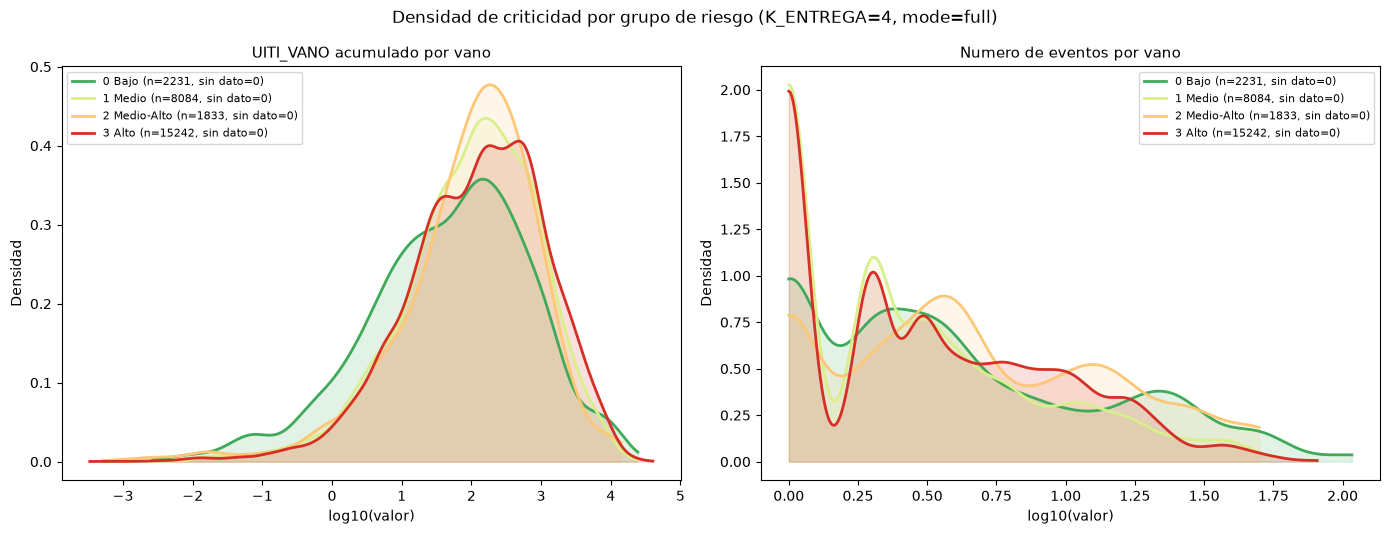


Distribucion CRUDA del numero de eventos por grupo (lectura correcta del panel derecho:
el KDE suaviza estos atomos enteros, no una densidad continua):
eventos        1     2     3    4    5+
riesgo                                 
Alto        4969  2494  1732  932  5115
Bajo         608   384   266  216   757
Medio       2962  1556   912  569  2085
Medio-Alto   395   225   205  258   750

Resumen numerico por grupo de riesgo (caracterizacion descriptiva, ver seccion 22):
                  n_vanos  uiti_media  uiti_mediana     uiti_p90  eventos_media  eventos_mediana
grupo riesgo                                                                                    
0     Bajo           2231  569.231668     65.394932  1172.993221       8.794711              3.0
1     Medio          8084  565.255572    125.384406  1358.875766       4.931222              2.0
2     Medio-Alto     1833  534.614670    130.367000  1097.816751       8.715767              4.0
3     Alto          15242  711.046010

In [40]:
from scipy.stats import gaussian_kde

cantidades = [
    ("UITI_VANO_acumulado", "UITI_VANO acumulado por vano", "viridis"),
    ("n_eventos", "Numero de eventos por vano", "magma"),
]
colores = plt.get_cmap("RdYlGn_r")(np.linspace(0.15, 0.9, len(nombres_por_grupo)))

fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.4))
for ax, (columna, titulo, _cmap) in zip(axes, cantidades):
    for g in sorted(nombres_por_grupo):
        serie = perfil_vanos.loc[perfil_vanos["grupo"] == g, columna].to_numpy(dtype=float)
        positivos = serie[np.isfinite(serie) & (serie > 0)]
        n_sin_dato = int(serie.size - positivos.size)
        if positivos.size < 2 or np.allclose(positivos, positivos[0]):
            print(f"  {titulo}: grupo {g} ({nombres_por_grupo[g]}) sin variacion suficiente "
                  "para un KDE; se omite su curva.")
            continue
        muestras_log = np.log10(positivos)
        densidad = gaussian_kde(muestras_log)
        rejilla = np.linspace(muestras_log.min(), muestras_log.max(), 400)
        ax.plot(rejilla, densidad(rejilla), color=colores[g], linewidth=2.0,
                label=f"{g} {nombres_por_grupo[g]} (n={positivos.size}, sin dato={n_sin_dato})")
        ax.fill_between(rejilla, densidad(rejilla), color=colores[g], alpha=0.15)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("log10(valor)")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8, loc="best")
fig.suptitle(
    f"Densidad de criticidad por grupo de riesgo (K_ENTREGA={K_ENTREGA}, mode={mode})", fontsize=12
)
fig.tight_layout()
KDE_FIGURE_PATH = FIGURES_DIR / f"mgcecdl_graphgated_nb12_{mode}_kde_criticidad.png"
fig.savefig(KDE_FIGURE_PATH, dpi=150, bbox_inches="tight")
print("Figura:", KDE_FIGURE_PATH)
plt.show()

print()
print("Distribucion CRUDA del numero de eventos por grupo (lectura correcta del panel derecho:")
print("el KDE suaviza estos atomos enteros, no una densidad continua):")
conteo_crudo = (
    perfil_vanos.assign(
        eventos=perfil_vanos["n_eventos"].fillna(0).astype(int).clip(upper=5).astype(str)
    )
    .replace({"eventos": {"5": "5+"}})
    .pivot_table(index="riesgo", columns="eventos", values="grupo", aggfunc="size", fill_value=0)
)
print(conteo_crudo.to_string())
print()
print("Resumen numerico por grupo de riesgo (caracterizacion descriptiva, ver seccion 22):")
resumen_final = perfil_vanos.groupby(["grupo", "riesgo"]).agg(
    n_vanos=("UITI_VANO_acumulado", "size"),
    uiti_media=("UITI_VANO_acumulado", "mean"),
    uiti_mediana=("UITI_VANO_acumulado", "median"),
    uiti_p90=("UITI_VANO_acumulado", lambda s: s.quantile(0.9)),
    eventos_media=("n_eventos", "mean"),
    eventos_mediana=("n_eventos", "median"),
)
print(resumen_final.to_string())
